# Workday Auto-Apply — Debug Notebook

Watch the agent navigate a Workday application **step-by-step**. Workday is
special — every interactive element is tagged with a stable
`data-automation-id` that is identical across all tenants
(`legalNameSection_firstName`, `pageFooterNextButton`, etc.). So we can fill
the standard fields by **exact selector** and bypass the LLM for the parts
we already know.

Pipeline:
1. **Detect Workday** — by URL or by counting `data-automation-id` elements.
2. **Cookie banner** — single deterministic click on `WORKDAY_COOKIE_ACCEPT`.
3. **Scan DOM** — same set-of-marks scan as the generic notebook.
4. **Deterministic prefill** — `workday_prefill()` fills first_name / last_name /
   city / phone by exact selector from your profile.
5. **Deterministic dropdowns** — country / phone device type / phone country code.
6. **Generic LLM fallback** — Step A + Step B from the generic notebook handle
   *only the fields Workday-prefill couldn't*.
7. **Execute** — fire whatever the LLM proposed.
8. **Advance** — click `WORKDAY_NEXT_BUTTON` ("Save and Continue"), follow new tabs.
9. **Loop** — re-scan, re-prefill, re-fallback, advance — repeat until "Submit".
10. **Cleanup**.

How to use: change `URL` in cell 3 to a Workday job page (anything ending in
`myworkdayjobs.com/...`), then run cells top-to-bottom with **Shift+Enter**.


In [114]:
import os, sys, json, base64, asyncio, threading
from pathlib import Path

# Same workaround as debug_agent.ipynb: Jupyter on Windows runs a
# SelectorEventLoop that can't spawn subprocesses -> Playwright fails.
# Run all Playwright coroutines on a dedicated background thread whose
# loop is a ProactorEventLoop.
class _AsyncRunner:
    def __init__(self):
        if sys.platform == "win32":
            asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
        self.loop = asyncio.new_event_loop()
        self._ready = threading.Event()
        self.thread = threading.Thread(target=self._serve, daemon=True)
        self.thread.start()
        self._ready.wait()

    def _serve(self):
        asyncio.set_event_loop(self.loop)
        self._ready.set()
        self.loop.run_forever()

    def run(self, coro):
        return asyncio.run_coroutine_threadsafe(coro, self.loop).result()


_BG = globals().get("_BG") or _AsyncRunner()
R   = _BG.run

sys.path.insert(0, str(Path.cwd()))
from dotenv import load_dotenv
load_dotenv()

# Generic agent helpers.
from auto_agent import (
    settle, collect_elements, elements_to_text, annotate_screenshot,
    execute_action, switch_if_new_tab, FLASH_MODEL,
)
# Workday-specific helpers.
from workday import (
    is_workday, is_workday_page, workday_prefill, workday_fill_dropdowns,
    WORKDAY_COOKIE_ACCEPT, WORKDAY_NEXT_BUTTON, WORKDAY_SUBMIT_BUTTON,
)
from profile_manager import load_profile, get_field_value, update_field
from apply_llm import llm_json

from IPython.display import Image, display

print("LLM driver :", os.getenv("APPLY_LLM"), "·", os.getenv("APPLY_MODEL"))
print("Email      :", (os.getenv("APPLY_EMAIL") or "")[:3] + "***")
print("Async loop :", type(_BG.loop).__name__)
print()
print("Workday selectors:")
print("  cookie accept :", WORKDAY_COOKIE_ACCEPT)
print("  next button   :", WORKDAY_NEXT_BUTTON)
print("  submit button :", WORKDAY_SUBMIT_BUTTON)


LLM driver : openai · gpt-5.4-mini
Email      : dee***
Async loop : ProactorEventLoop

Workday selectors:
  cookie accept : [data-automation-id='legalNoticeAcceptButton']
  next button   : [data-automation-id='pageFooterNextButton']
  submit button : [data-automation-id='bottom-navigation-next-button']


### Reload modules — run this ONCE after editing any .py file

Jupyter caches imported modules. After editing `auto_agent.py` or `apply_skills/base.py`, run this cell to pick up the new code without restarting the kernel (which would lose your browser page state).


In [115]:
import importlib
import apply_skills.base
import auto_agent
importlib.reload(apply_skills.base)
importlib.reload(auto_agent)
# Re-pull the symbols the notebook uses
from auto_agent import (collect_elements, annotate_screenshot,
                        elements_to_text, execute_action, settle,
                        switch_if_new_tab)
from apply_skills.base import dispatch_action
print("Reloaded — new click_option is now active.")


Reloaded — new click_option is now active.


## 1. Open the Workday page

Same persistent profile as the generic notebook so session cookies carry
over. Browser opens visibly — you'll do the **manual login / account
creation step** in the browser if Workday asks for it (Workday's
auth flow is too custom to automate cleanly). Once you're past login,
come back to this notebook and continue from cell 5.


In [116]:
# from playwright.async_api import async_playwright

# # ← change this to a real Workday job posting (anything ending in
# # myworkdayjobs.com or a vanity Workday domain like Blue Yonder's).
# URL = "https://amgen.wd1.myworkdayjobs.com/Careers/job/India---Hyderabad/Senior-Data-Scientist_R-230753/apply"
# PROFILE_DIR = Path("browser_profile")

# _p  = R(async_playwright().start())
# ctx = R(_p.chromium.launch_persistent_context(
#     str(PROFILE_DIR),
#     headless=False,
#     args=["--disable-blink-features=AutomationControlled", "--no-sandbox"],
#     viewport={"width": 1280, "height": 900},
# ))
# page = ctx.pages[0] if ctx.pages else R(ctx.new_page())
# R(page.goto(URL, wait_until="domcontentloaded"))
# print("URL  :", page.url)
# print("Title:", R(page.title()))


## 2. Workday detection

`is_workday()` is the URL check (`*.myworkdayjobs.com`).
`is_workday_page()` is the **fingerprint** check — many companies (Blue
Yonder, etc.) run Workday on a vanity domain, so we additionally look for
the presence of `data-automation-id` attributes (Workday tags everything
with them). If we see ≥10, or any of the known signature ids, it's Workday.


In [117]:
# print("is_workday(URL)         :", is_workday(page.url))
# print("is_workday_page(page)   :", R(is_workday_page(page)))

# # Show how many data-automation-id elements are on the page — Workday
# # pages typically have hundreds; non-Workday pages have zero.
# dai_count = R(page.locator("[data-automation-id]").count())
# print(f"data-automation-id count: {dai_count}")

# # Show a sample of the ids — handy to see if the field map needs to be extended.
# sample_ids = R(page.evaluate(
#     "() => [...new Set([...document.querySelectorAll('[data-automation-id]')]"
#     ".map(e => e.getAttribute('data-automation-id')))].slice(0, 20)"))
# print("\nSample data-automation-ids on this page:")
# for s in sample_ids:
#     print("  -", s)


## 3. Cookie banner — one deterministic click

Workday's cookie banner has a stable selector
(`legalNoticeAcceptButton`). One click, no LLM needed. Skips silently if
the banner isn't visible.


In [118]:
# banner = page.locator(WORKDAY_COOKIE_ACCEPT)
# visible = R(banner.count()) > 0 and R(banner.first.is_visible())
# print(f"Cookie banner visible: {visible}")
# if visible:
#     R(banner.first.click(timeout=3000))
#     R(page.wait_for_timeout(800))
#     print(f"  Clicked {WORKDAY_COOKIE_ACCEPT}")
# else:
#     print("  (skipped — banner not present)")


## 4. Scan page elements (with section_label)

Same as the generic notebook: wait for the page to stop mutating, then
collect every interactive element with `data-agent-idx` injected.


In [119]:
R(settle(page))
elements, idx_frame = R(collect_elements(page))
print(f"Found {len(elements)} interactive elements.\n")

# How many of them are Workday-tagged?
dai_in_scan = sum(1 for e in elements if e.get("dai") or "data-automation-id" in str(e))
print(f"Showing first 12 elements:")
for e in elements[:12]:
    print(" ", e)


Found 48 interactive elements.

Showing first 12 elements:
  {'idx': 0, 'tag': 'a', 'type': None, 'label': 'Skip to main content', 'box': [0, -493, 146, 19]}
  {'idx': 1, 'tag': 'a', 'type': None, 'label': '', 'box': [24, -277, 129, 19]}
  {'idx': 2, 'tag': 'button', 'type': None, 'label': 'English', 'box': [851, -325, 67, 21], 'widget': 'typeahead'}
  {'idx': 3, 'tag': 'button', 'type': None, 'label': 'Settings', 'box': [937, -325, 72, 21], 'widget': 'typeahead'}
  {'idx': 4, 'tag': 'button', 'type': None, 'label': 'deepakkumar007.jobs@gmail.com', 'box': [1029, -325, 215, 21], 'widget': 'typeahead'}
  {'idx': 5, 'tag': 'button', 'type': None, 'label': 'Amgen', 'box': [892, -292, 53, 21]}
  {'idx': 6, 'tag': 'button', 'type': None, 'label': 'Search for Jobs', 'box': [985, -292, 108, 21]}
  {'idx': 7, 'tag': 'button', 'type': None, 'label': 'Candidate Home', 'box': [1133, -292, 113, 21]}
  {'idx': 8, 'tag': 'button', 'type': None, 'label': 'main menu', 'box': [1199, -329, 66, 60], 'widg

### 4b. Inspect section_label coverage

Quick sanity-check that the DOM scan baked `section_label` into multi-row fields. If you see Work Experience / Education rows here, Step B's Tier-0 (section-mapped) will fire for them. Empty = single-row page (login etc.) — that's fine, Step B falls through to flat profile.


In [120]:
# Inspect section_label coverage of the most recent collect_elements scan.
from collections import Counter
_sec_counts = Counter()
_sample = {}  # section_label -> first 3 (idx, label) tuples
for _e in elements:
    _sl = (_e.get("section_label") or "").strip()
    if not _sl:
        continue
    _sec_counts[_sl] += 1
    _sample.setdefault(_sl, []).append((_e.get("idx"), _e.get("label", "")[:50]))

print(f"Total elements scanned : {len(elements)}")
print(f"Elements WITH section  : {sum(_sec_counts.values())}")
print(f"Unique sections        : {len(_sec_counts)}")
print()
if not _sec_counts:
    print("(no multi-row sections detected on this page — flat-profile pages are fine)")
else:
    for _sl, _n in sorted(_sec_counts.items()):
        print(f"  {_sl:30} ({_n} field(s))")
        for _idx, _lab in _sample[_sl][:3]:
            print(f"      [{_idx:>3}] {_lab}")


Total elements scanned : 48
Elements WITH section  : 34
Unique sections        : 3

  Education 1                    (12 field(s))
      [ 30] School or University*
      [ 31] Degree Master’s / Graduate Degree (5-6 year degree
      [ 32] Field of Study
  Work Experience 1              (13 field(s))
      [ 14] Delete
      [ 15] Job Title*
      [ 16] Company*
  Work Experience 2              (9 field(s))
      [ 21] Delete
      [ 22] Job Title*
      [ 23] Company*


### 4c. Inspect typeahead/select fields — which ones look filled?

Shows every button/select element with its captured `value`. If a field LOOKS filled in the browser but `value` is empty here, the DOM extraction needs tweaking.


In [121]:
# INSPECT TYPEAHEAD VALUES — verify _COLLECT_JS is capturing the
# displayed value of typeahead/button widgets so Step A can skip them.
for _e in elements:
    _tag    = _e.get("tag")
    _widget = _e.get("widget")
    if _tag not in ("button", "select") and _widget not in ("typeahead", "select"):
        continue
    _val = _e.get("value") or ""
    _state = "FILLED" if _val else "empty "
    print(f"  [{_e.get('idx'):>3}] {_state}  tag={_tag} widget={_widget!r:<11}  "
          f"label={(_e.get('label') or '')[:35]!r:<37} value={_val!r}")


  [  2] empty   tag=button widget='typeahead'  label='English'                             value=''
  [  3] empty   tag=button widget='typeahead'  label='Settings'                            value=''
  [  4] empty   tag=button widget='typeahead'  label='deepakkumar007.jobs@gmail.com'       value=''
  [  5] empty   tag=button widget=None         label='Amgen'                               value=''
  [  6] empty   tag=button widget=None         label='Search for Jobs'                     value=''
  [  7] empty   tag=button widget=None         label='Candidate Home'                      value=''
  [  8] empty   tag=button widget='typeahead'  label='main menu'                           value=''
  [  9] empty   tag=button widget=None         label='Back to Job Posting'                 value=''
  [ 10] empty   tag=button widget='typeahead'  label='Errors Found'                        value=''
  [ 11] empty   tag=button widget=None         label='Error-From'                          value=''


## 5. Set-of-marks screenshot

Red numbered boxes — the same visual grounding the LLM uses. On a Workday
form this will typically show first_name, last_name, address, phone, etc.


screenshot: 1265 x 3924 px  (231,904 bytes raw, 243,250 bytes marked)
elements: 48, y range: -160 to 3796


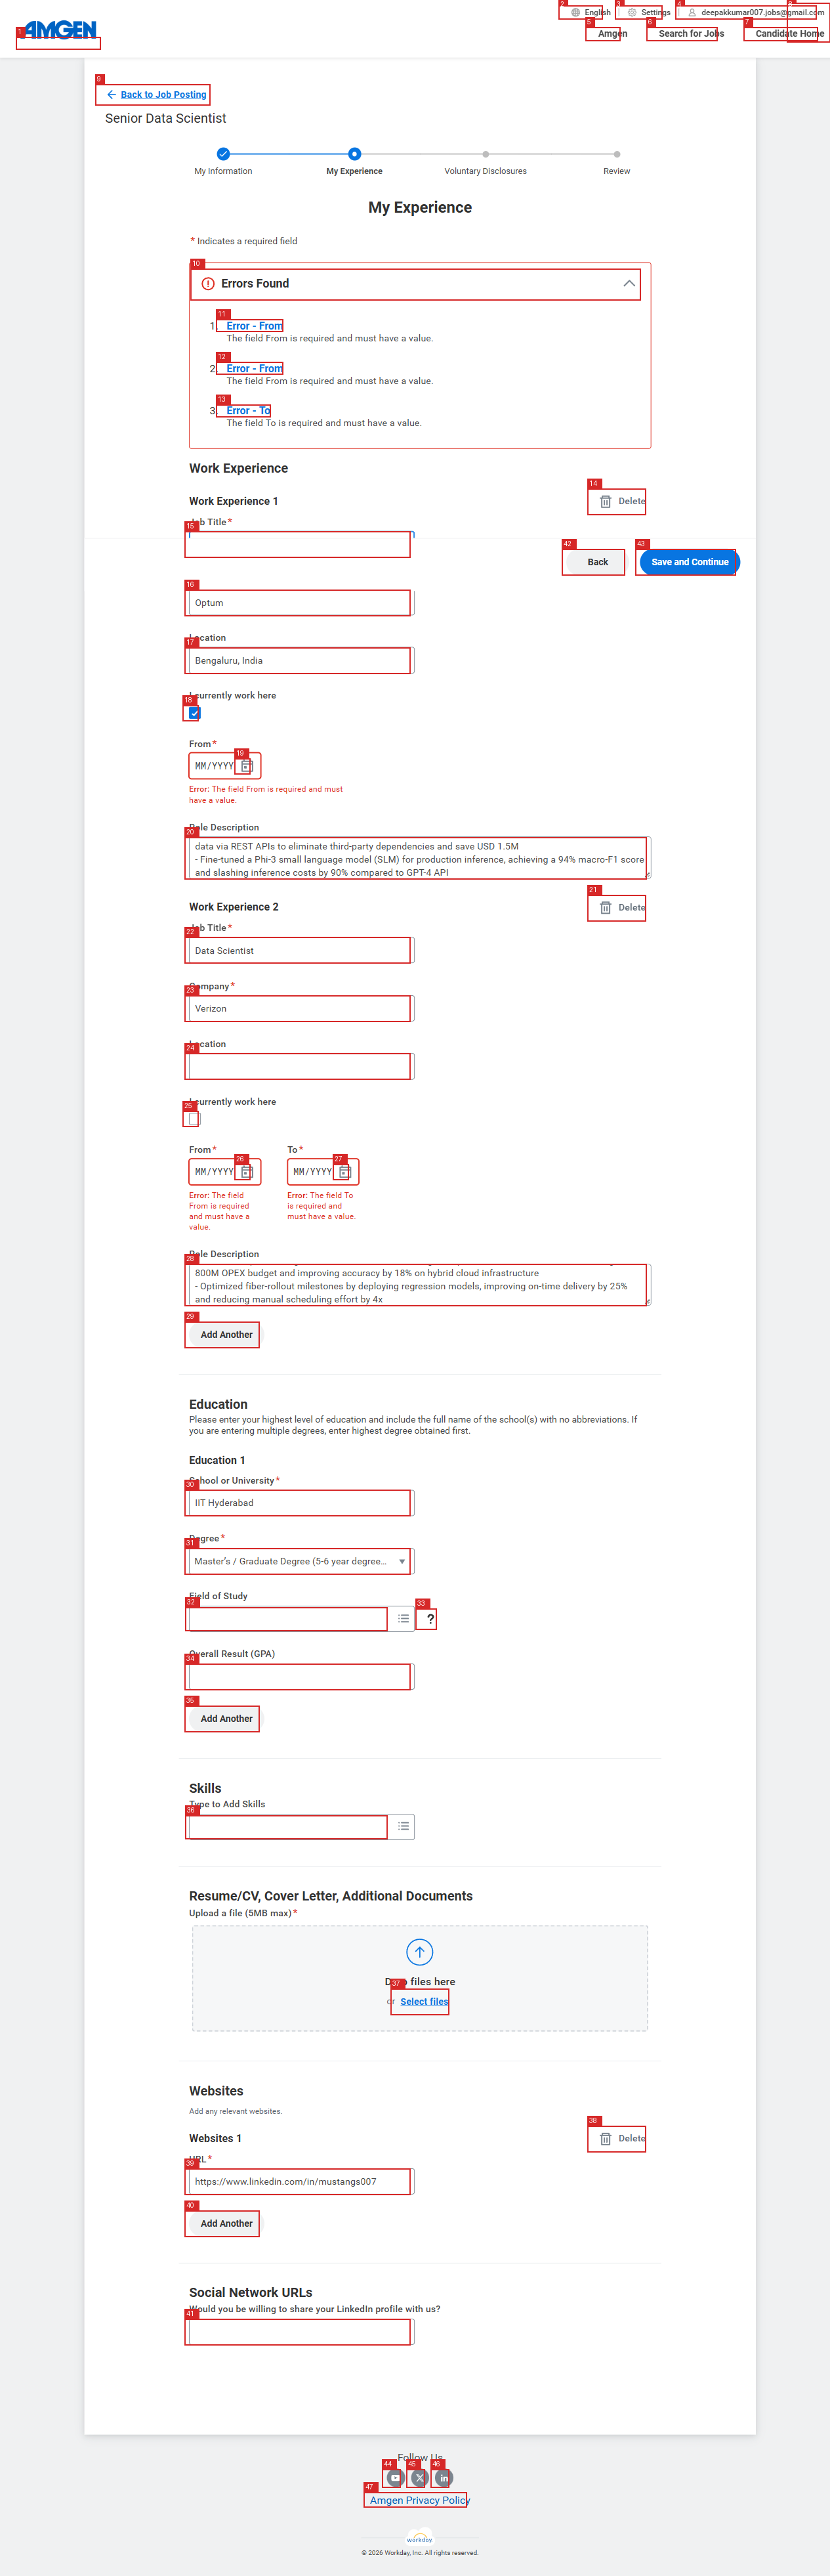

In [122]:
# Full-page screenshot, scroll-aware:
#   1. Scroll to top so getBoundingClientRect coords == document coords
#      (otherwise scrolled-out elements get negative y and the annotator
#      drops them, leaving a misleading half-truth picture for the LLM).
#   2. Re-scan elements at scrollY=0 — boxes now align with the document.
#   3. full_page=True stitches the entire scrollable area into one PNG.
#   4. Annotator draws boxes across the whole document height.
R(page.evaluate("window.scrollTo(0, 0)"))
R(page.wait_for_timeout(400))   # let sticky headers / lazy renders settle
elements, idx_frame = R(collect_elements(page))

raw_png    = R(page.screenshot(full_page=True))
marked_png = annotate_screenshot(raw_png, elements)

# Quick stats so you can see what changed.
from PIL import Image as _PI
import io as _io
_im = _PI.open(_io.BytesIO(raw_png))
print(f"screenshot: {_im.size[0]} x {_im.size[1]} px  ({len(raw_png):,} bytes raw, {len(marked_png):,} bytes marked)")
ys = [e["box"][1] for e in elements if e.get("box")]
print(f"elements: {len(elements)}, y range: {min(ys) if ys else 0} to {max(ys) if ys else 0}")

display(Image(data=marked_png))


## 6. Deterministic field prefill — the Workday cheat code

`workday_prefill()` walks the `_FIELDS` map in [workday.py](workday.py)
(currently: `legalNameSection_firstName`, `legalNameSection_lastName`,
`addressSection_city`, `phone-number`) and fills each by **exact selector**
from your profile. No LLM. No guessing. ~50ms per field.

`workday_fill_dropdowns()` does the same for country / phone-device-type /
phone-country-code, but ONLY when they're still showing the placeholder —
so re-running this cell is safe and idempotent.


In [123]:
USER_ID = 1
profile = load_profile(USER_ID)
print(f"profile.first_name = {profile.get('first_name')!r}")
print(f"profile.last_name  = {profile.get('last_name')!r}")
print(f"profile.city       = {profile.get('city')!r}")
print(f"profile.phone      = {profile.get('phone')!r}")
print(f"profile.country    = {profile.get('country')!r}")
print()

filled_fields = R(workday_prefill(page, profile))
print(f"Fields filled by selector: {filled_fields}")

filled_dropdowns = R(workday_fill_dropdowns(page, profile))
print(f"Dropdowns set:            {filled_dropdowns}")

R(settle(page))


profile.first_name = 'DEEPAK'
profile.last_name  = 'KUMAR'
profile.city       = 'Bengaluru'
profile.phone      = '9780616787'
profile.country    = 'India'

Fields filled by selector: []
Dropdowns set:            []


## 7. Auto-overview + auto-reveal loop (combines old 6c/6d)
Runs 6c (page overview) and 6d (click Adds) in a loop until either:
- no reveal actions remain (page is fully expanded), OR
- no progress detected (same reveals as last pass -> button is unclickable / maxed out), OR
- MAX_PASSES reached (safety cap).

At the end, the same globals as 6c are set: `last_overview`, `last_row_mappings`, `last_status`, etc. So Step A and Step B just work.


In [124]:
# 6 (auto). Loop 6c -> 6d -> 6c -> 6d until row_mappings populated and
# no more reveal actions are queued. Each pass clicks each queued Add
# ONCE then re-runs the overview, so indices stay fresh and buttons
# that move after a click are re-located via the next 6c pass.

import base64 as _b64
from google import genai as _genai

MAX_PASSES = 6  # safety cap; Workday usually settles in 3-4 passes
_gc_auto = globals().get("gemini_client") or _genai.Client(
    api_key=os.getenv("GEMINI_API_KEY", ""))

def _profile_brief_auto(prof):
    parts = []
    exp = prof.get("experience") or prof.get("work_experience")
    if isinstance(exp, list):
        parts.append(f"{len(exp)} work experiences")
    elif prof.get("current_company"):
        yr = prof.get("years_experience") or "?"
        parts.append(f"current job: {prof.get('current_title','')} @ "
                     f"{prof['current_company']} ({yr} total experience)")
    edu = prof.get("education")
    if isinstance(edu, list):
        parts.append(f"{len(edu)} education entries: " +
                     ", ".join(f"{e.get('degree','?')} {e.get('institution','')}"
                               for e in edu))
    for k in ("certifications", "languages", "skills"):
        v = prof.get(k)
        if isinstance(v, list) and v:
            parts.append(f"{len(v)} {k}")
    return "; ".join(parts) if parts else "minimal profile, no structured lists"

def _build_overview_prompt(brief):
    return f"""Look at this Workday application page. Red numbered boxes mark interactive elements.

USER PROFILE BRIEF: {brief}

Return STRICT JSON only:
{{
  "page_type":  "<login | register | profile | work_experience | education | questions | review | gateway | other>",
  "summary":    "<1-2 sentence overview>",
  "fields":     ["<each visible field with current state>"],
  "buttons":    ["<each visible action button>"],
  "errors":     ["<inline error messages, if any>"],
  "plan":       "<1-2 sentence high-level plan>",
  "status":     "<more_to_fill | ready_to_advance | blocked_validation | submit_review | done>",
  "remaining":  ["<labels of empty REQUIRED fields, empty list if none>"],
  "reveal_actions": [
    {{"index": <int>, "label": "<button label>", "section": "<Work Experience | Education | Certifications | Languages>", "reason": "<why>"}}
  ],
  "row_mappings": [
    {{
      "section":          "<e.g. Work Experience 1 / Education 2 / Certification 3>",
      "profile_list":     "<one of: experience | education | certifications>",
      "profile_index":    <0-based int into that list>,
      "key_value":        "<visible identifying value>",
      "element_indices":  [<list of all red-box numbers that belong to this row>]
    }}
  ]
}}

ROW MAPPINGS: one per visible multi-row container. For EACH visible row
(Work Experience 1, Work Experience 2, Education 1, etc.):
- Identify visible identifying value (company name / institution name).
- Match against profile entries 0-based. Brief lists experience and
  education in order: experience: A, B, C -> A=0, B=1, C=2.
- List EVERY red-box number that belongs to that row.
- If no match in profile brief, set profile_index = -1.
- If no multi-row sections exist, return row_mappings = [].

REVEAL ACTIONS — clicks needed BEFORE filling fields. RETURN EXACTLY ONE
ENTRY PER MISSING ROW (do NOT collapse multiple rows of the same section
into a single 'Add x3' — the loop will re-call you after each click).
- "Add" / "Add Another" / "+ Add" / "Expand all sections": one entry.
- ALWAYS include the SECTION name (Work Experience / Education / etc.)
  to disambiguate identically-labelled buttons across sections.
- If section already shows N rows and brief wants N (or fewer), do NOT
  emit a reveal for that section.
- Do NOT include the page's main 'Save and Continue' / 'Submit' here.

STATUS rules:
- submit_review = LAST page; only button is 'Submit Application'.
- blocked_validation = visible inline errors.
- more_to_fill = any required field still empty.
- ready_to_advance = all required fields filled, has 'Save and Continue'/'Next'.
- done = nothing to do.
"""

def _run_overview_pass():
    """One 6c pass. Returns the parsed overview dict."""
    R(page.evaluate("window.scrollTo(0, 0)"))
    R(page.wait_for_timeout(400))
    elems, idx_fr = R(collect_elements(page))
    raw = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, elems)
    prof = load_profile(globals().get("USER_ID", 1))
    brief = _profile_brief_auto(prof)
    img_b64 = _b64.b64encode(mark).decode()
    ov = llm_json(_build_overview_prompt(brief),
                  image_b64=img_b64,
                  gemini_client=_gc_auto, gemini_model=FLASH_MODEL)
    # Update globals for downstream cells.
    globals()["elements"]            = elems
    globals()["idx_frame"]           = idx_fr
    globals()["marked_png"]          = mark
    globals()["last_overview"]       = ov
    globals()["last_status"]         = ov.get("status", "unknown")
    globals()["last_reveal_actions"] = ov.get("reveal_actions", []) or []
    globals()["last_remaining"]      = ov.get("remaining", []) or []
    globals()["last_row_mappings"]   = ov.get("row_mappings", []) or []
    return ov

def _find_add_button(elems, want_label, want_section):
    """Find the best Add button in `want_section` whose label matches.
    Strategy: prefer button/link tags where label matches AND the element
    APPEARS-AFTER a section-header element whose text contains
    `want_section`. Falls back to label-only match."""
    wl = (want_label or "").strip().lower()
    ws = (want_section or "").strip().lower()
    if not wl:
        return None
    # Map idx -> position in scan order for "appears after" logic.
    pos_of = {e.get("idx"): i for i, e in enumerate(elems)}
    # Locate the most recent section-header element before each Add.
    section_pos = None
    if ws:
        for i, e in enumerate(elems):
            lab = (e.get("label") or "").strip().lower()
            if lab.startswith(ws):
                section_pos = i  # last header wins (the most recent one)
    # Candidate Adds: exact label match + button/link tag.
    cands = [e for e in elems
             if (e.get("label") or "").strip().lower() == wl
             and e.get("tag") in ("button", "a")]
    if not cands:
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower() == wl]
    if not cands:
        # Last resort: label starts with want_label.
        cands = [e for e in elems
                 if (e.get("label") or "").strip().lower().startswith(wl)
                 and e.get("tag") in ("button", "a")]
    if not cands:
        return None
    # Prefer candidates that appear AFTER the matched section header.
    if section_pos is not None:
        after = [c for c in cands if pos_of.get(c.get("idx"), -1) > section_pos]
        if after:
            # Earliest one after the header is "the Add for this section".
            after.sort(key=lambda c: pos_of.get(c.get("idx"), 10**9))
            return after[0]
    return cands[0]

print("="*72)
print(f"  AUTO-LOOP  (max passes={MAX_PASSES})")
print("="*72)

prev_signature = None
final_overview = None

for _pass in range(1, MAX_PASSES + 1):
    print(f"\n--- pass {_pass} : overview ---")
    ov = _run_overview_pass()
    final_overview = ov
    reveals = ov.get("reveal_actions") or []
    rows    = ov.get("row_mappings") or []
    status  = ov.get("status", "unknown")
    print(f"  status={status}   rows={len(rows)}   reveals={len(reveals)}")
    if rows:
        for rm in rows[:8]:
            print(f"    row: {rm.get('section','?'):28} -> "
                  f"{rm.get('profile_list','?')}[{rm.get('profile_index')}]  "
                  f"boxes={rm.get('element_indices') or []}")

    # ---- DETERMINISTIC count-based reveal generator ----
    # The LLM sometimes returns reveals=[] even when profile has more
    # entries than rows visible (because validation errors on the empty
    # row make it cautious). Trust profile counts vs row_mappings count.
    _prof_now = load_profile(globals().get("USER_ID", 1))
    SECTION_HEADER_HINT = {
        "experience":     ("Work Experience", ("Add", "Add Another", "+ Add")),
        "education":      ("Education",       ("Add", "Add Another", "+ Add")),
        "certifications": ("Certification",   ("Add", "Add Another", "+ Add")),
    }
    # Count visible rows by scanning DOM-baked section_labels on `elements`.
    # Replaces the old read of 6c's row_mappings (LLM-driven, unreliable).
    import re as _re_cnt
    _SEC_PAT = _re_cnt.compile(
        r"(Work Experience|Employment|Education|Certifications?|Languages?)\s+(\d+)",
        _re_cnt.I)
    _SEC_TO_LIST = {
        "work experience":  "experience",
        "employment":       "experience",
        "education":        "education",
        "certification":    "certifications",
        "certifications":   "certifications",
        "language":         "languages",
        "languages":        "languages",
    }
    _elems_now = globals().get("elements") or []
    _seen_by_list = {}
    for _e in _elems_now:
        _sl = (_e.get("section_label") or "").strip()
        if not _sl:
            continue
        _m = _SEC_PAT.search(_sl)
        if not _m:
            continue
        _w = _m.group(1).lower()
        _list = _SEC_TO_LIST.get(_w) or _SEC_TO_LIST.get(_w.rstrip("s"))
        if _list:
            _seen_by_list.setdefault(_list, set()).add(_sl)
    visible_count = {k: len(v) for k, v in _seen_by_list.items()}
    auto_reveals = []
    for plist, (hdr_hint, add_labels) in SECTION_HEADER_HINT.items():
        entries = _prof_now.get(plist) or []
        want, have = len(entries), visible_count.get(plist, 0)
        if want > have:
            auto_reveals.append({
                "section":      hdr_hint,
                "add_labels":   add_labels,
                "needed":       want - have,
            })
            print(f"  [counts] profile.{plist}: want={want} have={have}"
                  f" -> need {want - have} more Add click(s) in '{hdr_hint}'")

    if not reveals and not auto_reveals:
        print("  -> no reveals queued and counts match, exiting loop")
        break

    # No-progress detector: same reveals as last pass -> stuck.
    sig = tuple(sorted(
        ((r.get("label") or "").lower(),
         (r.get("section") or "").lower())
        for r in reveals
    ))
    if sig == prev_signature:
        print("  -> SAME reveals as previous pass, no progress; stopping")
        break
    prev_signature = sig

    print(f"  clicking {len(reveals)} reveal(s):")
    creds = {"email": os.getenv("APPLY_EMAIL", ""),
             "password": os.getenv("APPLY_PASSWORD", "")}
    elems_cur = globals().get("elements") or []
    idx_fr_cur = globals().get("idx_frame")
    for rev in reveals:
        label   = rev.get("label", "?")
        section = rev.get("section", "")
        target  = _find_add_button(elems_cur, label, section)
        if target is None:
            print(f"    SKIP '{label}' in '{section}' -> not found in elements")
            continue
        aidx = target["idx"]
        print(f"    click [{aidx}] '{target.get('label')}'  (section='{section}')")
        try:
            ok, note = R(execute_action(
                page, {"action": "click", "index": aidx},
                idx_fr_cur, elems_cur, "", creds,
            ))
            print(f"        {'OK ' if ok else 'FAIL'} {note}")
        except Exception as e:
            print(f"        FAIL {type(e).__name__}: {e}")
            continue
        R(settle(page))
        # Re-scan after each click for the next reveal's lookup.
        elems_cur, idx_fr_cur = R(collect_elements(page))
        globals()["elements"]  = elems_cur
        globals()["idx_frame"] = idx_fr_cur

    # Deterministic clicks based on profile-count gap. Click ONE per section
    # per pass; next pass picks up the next one. Stops cross-wiring because
    # we scope by section header.
    for ar in auto_reveals:
        hdr_hint = ar["section"]
        clicked  = False
        for lab in ar["add_labels"]:
            tgt = _find_add_button(elems_cur, lab, hdr_hint)
            if tgt is not None:
                aidx2 = tgt["idx"]
                print(f"  [counts-add] click [{aidx2}] '{tgt.get('label')}'  "
                      f"(section='{hdr_hint}')")
                try:
                    ok, note = R(execute_action(
                        page, {"action": "click", "index": aidx2},
                        idx_fr_cur, elems_cur, "", creds,
                    ))
                    print(f"            {'OK ' if ok else 'FAIL'} {note}")
                    R(settle(page))
                    elems_cur, idx_fr_cur = R(collect_elements(page))
                    globals()["elements"]  = elems_cur
                    globals()["idx_frame"] = idx_fr_cur
                    clicked = True
                except Exception as e:
                    print(f"            FAIL {type(e).__name__}: {e}")
                break
        if not clicked:
            print(f"  [counts-add] no Add button found for '{hdr_hint}' "
                  f"(tried labels: {ar['add_labels']})")
else:
    print(f"\n  reached MAX_PASSES ({MAX_PASSES}); stopping")

print("\n" + "="*72)
print("  AUTO-LOOP DONE")
print(f"  Final status        : {globals().get('last_status')}")
print(f"  Final row_mappings  : {len(globals().get('last_row_mappings') or [])} row(s)")
print(f"  Remaining required  : {len(globals().get('last_remaining') or [])}")
print("="*72)

# Final state ready: Step A and Step B can run on these globals as-is.


  AUTO-LOOP  (max passes=6)

--- pass 1 : overview ---
  status=blocked_validation   rows=3   reveals=0
    row: Work Experience 1            -> experience[0]  boxes=[15, 16, 17, 18, 19, 20]
    row: Work Experience 2            -> experience[1]  boxes=[22, 23, 24, 25, 26, 27, 28, 29]
    row: Education 1                  -> education[0]  boxes=[30, 31, 32, 33, 34, 35]
  [counts] profile.experience: want=3 have=2 -> need 1 more Add click(s) in 'Work Experience'
  [counts] profile.education: want=2 have=1 -> need 1 more Add click(s) in 'Education'
  clicking 0 reveal(s):
  [counts-add] click [29] 'Add Another'  (section='Work Experience')
            OK  click [29] Add Another
  [counts-add] click [37] 'Add Another'  (section='Education')
            OK  click [37] Add Another

--- pass 2 : overview ---
  status=blocked_validation   rows=5   reveals=1
    row: Work Experience 1            -> experience[0]  boxes=[8, 9, 10, 11, 12, 13]
    row: Work Experience 2            -> experience[

## 8. Step A — Page plan (LLM)

Single LLM call that turns the current page + screenshot into a JSON plan: a list of `actions` (fill / click / select / upload) and one `advance` button. If cell 7 (Auto-loop) said `ready_to_advance`, this step short-circuits — no LLM call.


In [125]:
# Cell 6c handoff: if it said ready_to_advance, skip the LLM call and
# emit a minimal advance-only plan. Execute's tier-1 deterministic
# WORKDAY_NEXT click will handle it.
if globals().get("last_status") == "ready_to_advance":
    print("6c said ready_to_advance -> skipping Step A LLM call.")
    _adv = (globals().get("last_overview") or {}).get("advance") or {"action": "next"}
    page_plan = {"page_type": "advance_only", "actions": [], "advance": _adv}
    print(json.dumps(page_plan, indent=2))
else:
    # Scroll to top + re-scan + full-page screenshot, then Step A.
    R(page.evaluate("window.scrollTo(0, 0)"))
    R(page.wait_for_timeout(400))
    elements, idx_frame = R(collect_elements(page))
    elements_text = elements_to_text(elements)
    raw_png    = R(page.screenshot(full_page=True))
    marked_png = annotate_screenshot(raw_png, elements)
    img_b64    = base64.b64encode(marked_png).decode()

    from google import genai
    gemini_client = genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))

    # --- Carry forward validation errors from 6c so the planner knows what to fix ---
    _last_ov = globals().get("last_overview") or {}
    _last_errors = _last_ov.get("errors", []) or []
    if _last_errors:
        _err_lines = "\n".join(f"  - {e}" for e in _last_errors)
        errors_note = (
            "\nVALIDATION ERRORS from a previous attempt on this page -- "
            "these MUST be fixed FIRST. Look up the matching field in the "
            "ELEMENTS list below by label and emit a fill/select action for it:"
            f"\n{_err_lines}\n"
            "If a field is already filled but flagged invalid (wrong date "
            "format, wrong URL, etc.), still include it with a corrected value.\n"
        )
    else:
        errors_note = ""

    prefilled = (globals().get("filled_fields") or []) + (globals().get("filled_dropdowns") or [])
    prefilled_note = (
        f"WORKDAY DETERMINISTIC PREFILL ran and filled these fields: {prefilled}. "
        "Do NOT re-emit actions for them."
        if prefilled else
        "WORKDAY DETERMINISTIC PREFILL ran but FILLED NOTHING on this page. "
        "You MUST fill every required empty field yourself, including first_name, "
        "last_name, city, phone — none of those are already filled."
    )

    # --- Step A: page-only plan ---
    PAGE_ONLY_PROMPT = f'''You are a Playwright automation planner for a single Workday page.
{errors_note}

    INPUTS
    - A FULL-PAGE screenshot (top-to-bottom of the entire scrollable form) with
      every interactive element labelled by a red numbered box (index).
    - A text listing of those elements. Filled fields are marked `(current: <value>)`.

    GOAL
    Return a JSON plan that fills EVERY required empty field on this page,
    plus any optional fields you can safely answer.

    {prefilled_note}

    A field is REQUIRED if its label ends with `*` or contains the word REQUIRED
    in the element listing. Visible inline error text like "is required and must
    have a value" also indicates an empty required field — fill those first.

    A field is ALREADY DONE only if its element-listing entry shows
    `(current: <non-placeholder value>)`. Treat `(current: Select One)` as EMPTY.

    OUTPUT SCHEMA (STRICT JSON):
    {{
      "page_type": "<login | register | gateway | profile | upload | questions | review | other>",
      "actions": [
        {{"index": <int>, "action": "<click|fill|select|check|upload>",
         "label": "<visible label>", "needs": "<snake_case key, omit for click>",
         "options": ["..."]}}
      ],
      "advance": {{"index": <int>, "action": "next | submit | none"}}
    }}

    ROW-AWARE NEEDS (CRITICAL — this is the most common source of bugs):
    - If the field is inside a MULTI-ROW SECTION header like "Work Experience 1",
      "Work Experience 2", "Education 1", "Education 2", "Certification 3", you
      MUST use a ROW-AWARE `needs` key, NOT a flat singular key:
        Work Experience row    -> job_title, job_company, job_location,
                                  job_start_date, job_end_date, job_description,
                                  job_is_current
        Education row          -> education_school, education_degree,
                                  education_field_of_study,
                                  education_start_year, education_end_year,
                                  education_start_date, education_end_date,
                                  education_gpa
        Certification row      -> certification_name, certification_issuer,
                                  certification_date
    - The FLAT keys current_title / current_company / city / school_or_university /
      university / degree / field_of_study / start_year / end_year are RESERVED
      for SINGLE-VALUE 'about you right now' fields (a standalone 'Current Company'
      input that asks for only ONE value). Do NOT use them for fields inside a
      numbered row container — they all collapse to the same value across rows.
    - If unsure whether a field is in a multi-row section, prefer the row-aware
      key. The downstream resolver will look at the screenshot and pick the
      right row from the structured profile.

    PRECEDENCE
    1. Skip fields with `(current: <real value>)` — they're done.
    2. Fill every required empty field.
    3. Dropdowns showing "Select One" are EMPTY — pick the right option with
       action="select" + options listed verbatim.
    4. For file inputs, action="upload" with needs="resume_file".

    REVEAL BUTTONS (Add / Add Another / "+ Add" inside multi-row sections like
    "Work Experience", "Education", "Certifications", "Languages"):
    - Emit ONLY the click for the Add button. DO NOT plan fields for the
      section's rows yet — they don't exist in the DOM until Add is clicked.
    - After Add is clicked, the user will re-run Step A to scan and plan the
      newly-revealed fields.
    - If multiple Add buttons exist (Work Experience AND Education both need
      rows), emit only ONE Add click per plan — handle the others on the
      next iteration.

    TYPEAHEAD CHIP-LIST FIELDS — SKIP ENTIRELY:
    - These are multi-value inputs where you type a term, an autocomplete
      dropdown appears, you click a match to add it as a chip, repeat.
    - Examples: "Skills" (Type to Add Skills), "Languages", "Programming
      Languages", "Areas of Expertise", "Certifications".
    - These need a per-chip type-and-pick loop that a single fill action
      can't do. DO NOT emit a fill or select action for them. The user
      will populate them manually in the browser.

    ADVANCE — pick the right forward button:
    - "Save and Continue" / "Continue" / "Next" → action="next".
    - "Sign In" / "Create Account" → action="next".
    - "Submit Application" on the FINAL review page → action="submit".
    - MODAL / POPUP after clicking Apply — When you can see a centered
      dialog whose title is "Start Your Application" (or similar) AND it
      shows multiple buttons such as "Autofill with Resume", "Apply Manually",
      "Use My Last Application", you MUST pick "Apply Manually" as ADVANCE.
      Reason: the underlying job-page "Apply" button has ALREADY been clicked
      (that's what opened the modal). Clicking it again hits the modal's
      backdrop and CLOSES the modal — infinite ping-pong. The forward action
      is the modal's own "Apply Manually". Set page_type="gateway", put the
      "Apply Manually" index in ADVANCE with action="next", leave `actions`
      EMPTY. NEVER pick "Autofill with Resume" (opens a file picker we
      don't drive) and NEVER pick "Use My Last Application" (fails for new
      candidates).
    - LANDING / JOB-DESCRIPTION pages (no form fields, only an "Apply" /
      "Apply Now" / "Apply Manually" / "Start Application" button) → set
      page_type="gateway" and put that button index in ADVANCE ONLY with
      action="next". Leave `actions` EMPTY. Do NOT also list it in `actions`.
    - ONLY set action="none" if the page genuinely has no forward button.

    NEVER include in actions OR advance:
    - "Skip to main content" (off-viewport accessibility link)
    - Sign Out, Log Out, Sign Off
    - Header nav: Careers Home, Search for Jobs, Candidate Home, Job Alerts,
      Drop off your CV/Resume
    - Language switcher, settings, account-email button
    - Footer: Privacy Policy, social icons (X, LinkedIn, YouTube, Facebook)
    - "Back to Job Posting", "Delete" / "Remove" buttons
    - Help / "?" / "Show help for X" icons
    - "View All N Jobs" / "Similar Jobs" cards
    - Typeahead chip-list fields (see TYPEAHEAD rule above)

    DO NOT DUPLICATE: an index in `advance` MUST NOT also appear in `actions`.

    CANONICAL `needs` KEYS:

    SINGLE-VALUE keys (use ONLY for standalone 'about you' fields, NEVER inside
    a numbered multi-row container):
      email, password, first_name, last_name, full_name,
      phone, phone_country_code, phone_device_type, phone_extension,
      street_address, address_line_2, city, state, postal_code, country, linkedin,
      current_company, current_title, years_experience, expected_ctc, current_ctc,
      notice_period, willing_to_relocate, work_authorization, visa_sponsorship,
      highest_education, resume_file, cover_letter_file.

    ROW-AWARE keys (use for Work Experience N / Education N / Certification N rows):
      job_title, job_company, job_location, job_start_date, job_end_date,
      job_description, job_is_current,
      education_school, education_degree, education_field_of_study,
      education_start_year, education_end_year,
      education_start_date, education_end_date, education_gpa,
      certification_name, certification_issuer, certification_date.
    For Add/reveal buttons, use needs="" (omit) — they're clicks, not values.

    ELEMENTS:
    {elements_text}
    '''

    page_plan = llm_json(PAGE_ONLY_PROMPT, image_b64=img_b64,
                         gemini_client=gemini_client, gemini_model=FLASH_MODEL)
    print("STEP A — page plan:")
    print(json.dumps(page_plan, indent=2))


STEP A — page plan:
{
  "page_type": "other",
  "actions": [
    {
      "index": 71,
      "action": "select",
      "label": "Degree Master\u2019s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required",
      "needs": "education_degree",
      "options": [
        "Master\u2019s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required"
      ]
    }
  ],
  "advance": {
    "index": 83,
    "action": "next"
  }
}


## 9. Step B — Map values (section-mapped Tier-0)

Walks Step A's `actions[]`. For each action, looks up the value via:
1. **Section-mapped** (Tier-0) — reads `element.section_label` set by the DOM scan, calls `get_field_value(label, profile, section_label=...)`. The deterministic per-row lookup that replaces the old `row_mappings` Tier-0.
2. Flat profile (whole-token match).
3. `profile-llm` (LLM resolution from structured profile + screenshot).
4. `resume->profile` (LLM extract from resume text, persisted).

HOP 1 / 2 / 3 diagnostics print before the resolve loop so you can see exactly which tier fired per field.


In [126]:
# --- Step B: map values from profile, fall back to resume, persist ---
import os as _os
EXTRACT_PROMPT = '''From the RESUME below, extract a value for the field described.
Return STRICT JSON only: {{"value": "<value, or empty string if not present>"}}

FIELD KEY:   {key}
FIELD LABEL: {label}
{opts_block}

RESUME:
{resume}
'''

resume_text = profile.get("_resume_text", "")

# Confirmation-field aliases — Verify/Confirm fields are re-entries of the
# original. Resolves "verify_password" -> "password" etc.
KEY_ALIASES = {
    "verify_password":    "password",
    "confirm_password":   "password",
    "password_confirm":   "password",
    "password_verify":    "password",
    "retype_password":    "password",
    "re_enter_password":  "password",
    "reenter_password":   "password",
    "new_password":       "password",
    "verify_new_password":"password",
    "verify_email":       "email",
    "confirm_email":      "email",
    "email_confirm":      "email",
    "reenter_email":      "email",
}

def _looks_like_path(val):
    """File-path sanity check for *_file values cached in profile.
    Plain words like 'DEEPAK KUMAR' fail; real paths pass."""
    if not val: return False
    s = str(val).strip()
    if len(s) < 4: return False
    if "/" in s or "\\" in s: return True
    lower = s.lower()
    for ext in (".pdf", ".doc", ".docx", ".txt", ".rtf", ".odt", ".pages"):
        if lower.endswith(ext): return True
    return False


def _nearby_labels(aidx, n_before=8):
    """Return the labels of the `n_before` elements immediately before
    `aidx` in the scan. These usually contain the row's company name /
    section header — perfect for disambiguating which experience[]
    row a generic "From*" / "To*" field belongs to."""
    els = globals().get("elements") or []
    pos = next((i for i, e in enumerate(els) if e.get("idx") == aidx), None)
    if pos is None:
        return []
    start = max(0, pos - n_before)
    out = []
    for e in els[start:pos]:
        lab = (e.get("label") or "").strip()
        if lab:
            out.append(lab[:60])
    return out

def _cache_key(key, label, neighbors=None):
    """Cache key combining (key, label, neighbor-signature). The neighbor
    signature distinguishes two rows whose field labels are identical
    (e.g. two 'From*' inputs, one for Optum one for Verizon)."""
    lab = " ".join((label or "").lower().split())
    sig = "|".join((s or "").lower().strip()[:30] for s in (neighbors or []))
    sig = sig[:120]  # keep cache keys bounded
    return f"{(key or '').strip().lower()}|{lab}|{sig}"

# ============================================================
# [DEPRECATED] Replaced by element.section_label baked in at
# auto_agent.collect_elements time (see plan luminous-dazzling-
# turing.md). Kept here as commented reference for the legacy
# row_mappings approach. The 'section-mapped' tier below uses
# profile_manager.get_field_value(..., section_label=...) and
# does not need cell 6c's row_mappings JSON anymore.
# ============================================================
# # ----- Row-mapping tier (fed by cell 6c's row_mappings output) -----
# # Maps row-aware `needs` keys to nested-list paths in profile.json.
# ROW_NEEDS_MAP = {
    # # Work-experience row fields -> profile.experience[N].<key>
    # "job_title":        ("experience", "title"),
    # "job_company":      ("experience", "company"),
    # "job_location":     ("experience", "location"),
    # "job_start_date":   ("experience", "start_date"),
    # "job_end_date":     ("experience", "end_date"),
    # "job_description":  ("experience", "description"),
    # "job_is_current":   ("experience", "is_current"),
    # # Education row fields -> profile.education[N].<key>
    # "education_school":         ("education", "institution"),
    # "education_degree":         ("education", "degree"),
    # "education_field_of_study": ("education", "field_of_study"),
    # "education_start_year":     ("education", "start_year"),
    # "education_end_year":       ("education", "end_year"),
    # "education_start_date":     ("education", "start_date"),
    # "education_end_date":       ("education", "end_date"),
    # "education_gpa":            ("education", "gpa"),
    # # Certifications
    # "certification_name":   ("certifications", "name"),
    # "certification_issuer": ("certifications", "issuer"),
    # "certification_date":   ("certifications", "date"),
# }

# def _row_for(aidx, row_mappings):
    # """Return the row_mapping entry whose element_indices contains aidx,
    # or None."""
    # if aidx is None or not row_mappings:
        # return None
    # for rm in row_mappings:
        # if aidx in (rm.get("element_indices") or []):
            # return rm
    # return None

# def _from_row_mapping(needs, aidx, row_mappings, profile):
    # """Tier-0 lookup: if `needs` is row-aware AND aidx falls in a known row,
    # return profile.<list>[<index>].<key>. Verifies the row by checking
    # key_value matches the profile entry's primary field (company/institution).
    # Returns (value, source) or (None, None)."""
    # if needs not in ROW_NEEDS_MAP:
        # return None, None
    # rm = _row_for(aidx, row_mappings)
    # if rm is None:
        # return None, None

    # list_name, sub_key = ROW_NEEDS_MAP[needs]
    # # Sanity-check: row_mappings says this row's profile_list, must match.
    # if (rm.get("profile_list") or "").lower() != list_name:
        # return None, None

    # idx = rm.get("profile_index")
    # if idx is None or idx < 0:
        # return None, None

    # entries = profile.get(list_name) or []
    # if not (0 <= idx < len(entries)):
        # return None, None
    # entry = entries[idx]

    # # Verify key_value matches the profile entry's primary identifier.
    # # For experience -> company; education -> institution; certifications -> name.
    # primary_key = {"experience": "company", "education": "institution",
                   # "certifications": "name"}.get(list_name, "")
    # expected_kv = str(entry.get(primary_key) or "").strip().lower()
    # seen_kv     = str(rm.get("key_value") or "").strip().lower()
    # if expected_kv and seen_kv and expected_kv not in seen_kv and seen_kv not in expected_kv:
        # # Row map disagrees with profile -> don't trust; fall through.
        # print(f"    (row-map mismatch at [{aidx}]: 6c saw {seen_kv!r}, "
              # f"profile {list_name}[{idx}] is {expected_kv!r}; falling through)")
        # return None, None

    # val = entry.get(sub_key)
    # if val is None or val == "":
        # return None, None
    # return str(val), f"row-mapped (experience[{idx}])" if list_name == "experience" else f"row-mapped ({list_name}[{idx}])"



# ── NEW: section-aware tier (replaces row_mappings) ─────────────────────────
# Every element gets a deterministic `section_label` from auto_agent's DOM
# scan (e.g. "Work Experience 2"). Step B reads it from `elements` and asks
# profile_manager.get_field_value to do the row-aware lookup.
def _element_section(aidx):
    """Return the section_label of the element with this aidx, or ''."""
    els = globals().get("elements") or []
    for e in els:
        if e.get("idx") == aidx:
            return (e.get("section_label") or "").strip()
    return ""

def _from_section(key, label, aidx, profile):
    """Tier 0: deterministic per-row lookup via DOM-baked section_label.

    Returns (value, source) or (None, None). The source string includes
    the section so HOP 3 debug output stays informative."""
    sl = _element_section(aidx)
    if not sl:
        return None, None
    from profile_manager import get_field_value as _gfv
    # Use the user-visible LABEL (not the row-aware needs key) so the
    # label->sub_key alias table in profile_manager has the most signal.
    val = _gfv(label, profile, section_label=sl)
    if val is None or val == "":
        return None, None
    return str(val), f"section-mapped ({sl})"


def _from_profile(key, label, aidx=None):
    # 0) Check the LLM-resolution cache first. Cheap O(1) lookup. The cache
    #    key includes neighbor labels so row-specific entries stay distinct.
    cache = profile.get("_llm_resolved") or {}
    neighbors = _nearby_labels(aidx) if aidx is not None else []
    ck = _cache_key(key, label, neighbors)
    if ck in cache and cache[ck]:
        return str(cache[ck])
    # Fall back to checking the label-only cache key (for entries written
    # before neighbor-context was added).
    ck_legacy = _cache_key(key, label)
    if ck_legacy in cache and cache[ck_legacy]:
        return str(cache[ck_legacy])

    # 1) Alias resolution — "verify_password" -> "password" etc.
    if key in KEY_ALIASES:
        key = KEY_ALIASES[key]

    # 2) File-path fields: validate the cached value before returning it.
    #    Earlier resume-extract runs polluted profile["resume_file"] with
    #    things like "DEEPAK KUMAR". Auto-clean and treat as missing.
    if key.endswith("_file"):
        cached = profile.get(key)
        if cached and not _looks_like_path(cached):
            print(f"    [cleanup] profile['{key}']={cached!r} doesn't look "
                  f"like a path -> removing")
            try:
                p = load_profile(USER_ID)
                p.pop(key, None)
                from profile_manager import save_profile
                save_profile(USER_ID, p)
                # mutate the in-scope `profile` to match disk
                profile.pop(key, None)
            except Exception as e:
                print(f"    [cleanup] couldn't persist: {e}")
            return None
        # Honor APPLY_RESUME_PATH env var if set (e.g. for testing).
        if key == "resume_file" and not cached:
            env_path = _os.getenv("APPLY_RESUME_PATH") or _os.getenv("RESUME_PATH")
            if env_path and _os.path.exists(env_path):
                return env_path
        return str(cached) if cached else None

    # 3) Regular profile lookup.
    if key and profile.get(key):
        return str(profile[key])
    # 4) Loose label match via the project's existing field-map heuristic.
    v = get_field_value(label or key or "", profile)
    return v or None


def _from_profile_llm(key, label, options=None, aidx=None, image_b64=None):
    """LLM lookup over the structured profile + screenshot.

    Now also receives:
    - `aidx` -> fetch neighbor element labels for text disambiguation.
    - `image_b64` -> marked screenshot with red index boxes for VISUAL
      disambiguation. The LLM can SEE which row a field belongs to by
      looking at the red box numbers (matches aidx) and the surrounding
      visible labels (Company name shows in the row's other inputs).
    """
    neighbors = _nearby_labels(aidx) if aidx is not None else []
    # Build a compact context: profile minus the heavy _resume_text key.
    ctx = {k: v for k, v in profile.items() if k != "_resume_text"}
    opts_block = ""
    if options:
        opts_block = ("ALLOWED OPTIONS (pick the closest one verbatim):\n- "
                      + "\n- ".join(options))
    neighbors_block = ""
    if neighbors:
        neighbors_block = (
            "\nNEARBY LABELS on the page (use these to identify which row "
            "of experience[]/education[] this field belongs to — usually the "
            "row's company or institution name is here):\n  - "
            + "\n  - ".join(neighbors)
        )
    visual_block = ""
    if image_b64:
        visual_block = (
            f"\nVISUAL: a screenshot of the page is provided. The target "
            f"field is the input/control with red box number [{aidx}]. "
            "Look at the visible labels and FILLED values of ADJACENT boxes "
            "(particularly the row's Company* / School* / Institution* "
            "fields) to identify which row of experience[] or education[] "
            "this field belongs to. Then pull the right value from the JSON."
        )
    prompt = f"""Find a value for ONE form field from the user's structured profile.

PROFILE (JSON):
{json.dumps(ctx, indent=2)}

FIELD KEY:   {key or "(none)"}
FIELD LABEL: {label or "(none)"}
TARGET BOX:  [{aidx}]
{visual_block}
{neighbors_block}
{opts_block}

INSTRUCTIONS:
- If the label contains a row hint like "Work Experience 1", "Education 2",
  "Job Title 3", use it to pick the right entry from experience[] / education[].
  Row 1 = index 0.
- For job dates (From, To, start_date, end_date), prefer MM/YYYY format from
  experience[N].start_date / end_date. If end is null AND is_current is true,
  return empty string (the page checkbox "I currently work here" handles it).
- For job description / role description / responsibilities, return the
  experience[N].description text verbatim.
- For school / university / institution names, prefer education[N].institution.
- For degree, education[N].degree.
- For field of study, education[N].field_of_study.
- For years (graduation, start, end), education[N].start_year / end_year.
- If the field is NOT obviously in the profile, return empty string.
- DO NOT invent values. DO NOT use the user's name as a substitute for descriptions.

Return STRICT JSON only: {{"value": "<value, or empty string>"}}
"""
    out = llm_json(prompt, image_b64=image_b64,
                   gemini_client=gemini_client, gemini_model=FLASH_MODEL)
    val = ((out or {}).get("value") or "").strip() or None
    if val:
        # Cache by (needs, label) so future deterministic lookups find it
        # without a second LLM call. Persist to disk so the cache survives
        # across notebook restarts.
        try:
            cache = profile.setdefault("_llm_resolved", {})
            cache[_cache_key(key, label, neighbors)] = val
            from profile_manager import save_profile as _save
            _save(USER_ID, profile)
        except Exception as _e:
            print(f"    (cache-write failed: {_e})")
    return val


def _from_resume(key, label, options=None):
    if not resume_text or (key or "").endswith("_file"):
        return None   # file-path fields can't be extracted from resume text
    if key in KEY_ALIASES:
        key = KEY_ALIASES[key]
    opts_block = ""
    if options:
        opts_block = "ALLOWED OPTIONS (pick the closest one verbatim):\n- " + "\n- ".join(options)
    prompt = EXTRACT_PROMPT.format(key=key or "(none)", label=label or "(none)",
                                   opts_block=opts_block, resume=resume_text[:12000])
    out = llm_json(prompt, gemini_client=gemini_client, gemini_model=FLASH_MODEL)
    return ((out or {}).get("value") or "").strip() or None


# Reuse Step A's marked screenshot for visual disambiguation in
# _from_profile_llm. If absent (cell run out of order), skip vision.
_marked = globals().get("marked_png")
_step_b_img = base64.b64encode(_marked).decode() if _marked else None
if _step_b_img:
    print(f"(Step B will use Step A's screenshot for visual row disambiguation)")
else:
    print(f"(no Step A screenshot in scope; Step B running text-only)")

# ===== HOP DIAGNOSTICS (read this first when rows are wrong) =====
# HOP 1 now shows the section_label distribution from the DOM scan
# (auto_agent.collect_elements). This replaces the old row_mappings view.
_dbg_secs = {}
for _e in (globals().get("elements") or []):
    _sl = (_e.get("section_label") or "").strip()
    if _sl:
        _dbg_secs[_sl] = _dbg_secs.get(_sl, 0) + 1
print("="*72)
print(f"  HOP 1 - section_label distribution from DOM scan: "
      f"{len(_dbg_secs)} unique section(s)")
print("="*72)
if not _dbg_secs:
    print("  (no section_labels detected on any element)")
    print("  -> Tier 0 (section-mapped) cannot fire. Single-row pages still")
    print("     work via the flat-profile fallback below.")
else:
    for _sl, _n in sorted(_dbg_secs.items()):
        print(f"  {_sl:30}  ({_n} field(s))")

print()
print("="*72)
print(f"  HOP 2 - needs emitted by Step A ({len(page_plan.get('actions') or [])} action(s)):")
print("="*72)
# Row-aware needs are no longer load-bearing (section_label is) — but we
# still flag mismatches so the user can spot Step A drift.
_row_aware = {"job_title","job_company","job_location","job_start_date",
              "job_end_date","job_description","job_is_current",
              "education_school","education_degree","education_field_of_study",
              "education_start_year","education_end_year","education_gpa",
              "certification_name","certification_issuer","certification_date"}
_flat_singular = {"current_title","current_company","city","university",
                  "degree","field_of_study","start_year","end_year",
                  "school_or_university"}
for a in page_plan.get("actions", []):
    nds  = (a.get("needs") or "").strip()
    aidx = a.get("index")
    lab  = (a.get("label") or "")[:50]
    sl   = _element_section(aidx)
    in_section = bool(sl)
    if in_section and nds in _row_aware:
        tag = f"OK section={sl!r}"
    elif in_section and nds in _flat_singular:
        tag = (f"WARN section={sl!r} but needs is flat — Step A drift "
               f"(still resolves via section_label)")
    elif in_section:
        tag = f"section={sl!r}"
    elif not nds:
        tag = "(no needs)"
    else:
        tag = "flat (no section)"
    print(f"  [{aidx:>3}] needs={nds!r:<28} label={lab!r:<35} {tag}")

print()
print("="*72)
print("  HOP 3 - Tier 0 resolution per action (row-mapped or fallthrough):")
print("="*72)

enriched = {"page_type": page_plan.get("page_type"), "actions": [],
            "advance": page_plan.get("advance")}

for a in page_plan.get("actions", []):
    key, label, act = (a.get("needs") or "").strip(), a.get("label") or "", a.get("action")
    if act == "click" or not key:
        enriched["actions"].append({**a, "value": "", "source": "n/a"})
        continue
    _aidx = a.get("index")
    # Tier 0 (NEW): section-mapped via element.section_label from DOM scan.
    # Replaces the old row_mappings approach — see luminous-dazzling-turing.md.
    _sv, _ss = _from_section(key, label, _aidx, profile)
    if _sv is not None:
        value, source = _sv, _ss
        print(f"  [{_aidx:>3}] needs={key!r:<22} SECTION-MAPPED -> {_sv!r}  ({_ss})")
    else:
        _sl = _element_section(_aidx)
        _reason = ("no section_label on element"
                   if not _sl
                   else f"section_label={_sl!r} but label/sub-key didn't match entry")
        print(f"  [{_aidx:>3}] needs={key!r:<22} section miss ({_reason}) -> flat profile")
        value, source = _from_profile(key, label, aidx=_aidx), None
    if value and source is None:
        # _from_profile returned a value with no source yet -> set source.
        cache = profile.get("_llm_resolved") or {}
        _neighbors = _nearby_labels(_aidx) if _aidx is not None else []
        if (cache.get(_cache_key(key, label, _neighbors)) == value
                or cache.get(_cache_key(key, label)) == value):
            source = "profile-cached"
        elif key in KEY_ALIASES:
            source = f"profile (alias->{KEY_ALIASES[key]})"
        else:
            source = "profile"
    elif value:
        # Already set by Tier 0 (row-mapping). Keep its source label.
        pass
    elif (val := _from_profile_llm(key, label, a.get("options"),
                                        aidx=_aidx, image_b64=_step_b_img)):
        # LLM found it in the structured profile (e.g. nested experience[] / education[]).
        value, source = val, "profile-llm"
    elif (val := _from_resume(key, label, a.get("options"))):
        value = val
        # Persist under the RESOLVED key (so "verify_password" doesn't
        # become its own profile field).
        save_key = KEY_ALIASES.get(key, key)
        # Don't persist a value that doesn't look like a path under a *_file key.
        if save_key.endswith("_file") and not _looks_like_path(value):
            print(f"    [refuse-persist] {save_key!r}={value!r} isn't a file path; "
                  f"marking source=missing instead")
            value, source = None, None
        else:
            update_field(USER_ID, save_key, value)
            profile = load_profile(USER_ID)
            source = "resume->profile"
    enriched["actions"].append({**a, "value": value or "", "source": source or "missing"})

print("STEP B — enriched plan:")
print(json.dumps(enriched, indent=2))

from collections import Counter
print("\nsources:", dict(Counter(a.get("source") for a in enriched["actions"])))


(Step B will use Step A's screenshot for visual row disambiguation)
  HOP 1 - section_label distribution from DOM scan: 8 unique section(s)
  Education 1                     (12 field(s))
  Work Experience 1               (13 field(s))
  Work Experience 2               (8 field(s))
  Work Experience 3               (8 field(s))
  Work Experience 4               (8 field(s))
  Work Experience 5               (8 field(s))
  Work Experience 6               (8 field(s))
  Work Experience 7               (9 field(s))

  HOP 2 - needs emitted by Step A (1 action(s)):
  [ 71] needs='education_degree'           label='Degree Master’s / Graduate Degree (5-6 year degree' OK section='Education 1'

  HOP 3 - Tier 0 resolution per action (row-mapped or fallthrough):
  [ 71] needs='education_degree'     SECTION-MAPPED -> 'MTech'  (section-mapped (Education 1))
STEP B — enriched plan:
{
  "page_type": "other",
  "actions": [
    {
      "index": 71,
      "action": "select",
      "label": "Degree Ma

## 9b. Convergence fill — deterministic + error-driven (RECOMMENDED)

**Run this INSTEAD of Step A → Step B → Review → Execute for form pages.**

Root-cause fix for the whack-a-mole: drops the LLM planner from the critical path. For every field on the page it asks the profile "do I have a value?" (section-aware, deterministic), fills it, clicks Save & Continue, and treats the page's own validation errors as the authoritative to-do list — looping until the page accepts the input or a field genuinely has no profile data. Errors can't resurface because it never advances until they all clear. Also auto-deletes phantom rows and skips already-filled fields.


In [127]:
# ============================================================================
# CONVERGENCE FILL — deterministic, error-driven, self-correcting.
# ============================================================================
# Philosophy (why this replaces Step A -> B -> Review -> Execute for form pages):
#   * The LLM planner (Step A) GUESSES what's on the page -> phantom rows,
#     missed dates/uploads, wrong indices. We drop it from the critical path.
#   * Instead: for EVERY field on the page, ask the profile "do I have a
#     value?" via get_field_value(label, profile, section_label). Fill it.
#     100% deterministic, section-aware (correct row every time).
#   * Then click Save & Continue. The PAGE'S validation errors are the
#     authoritative to-do list -- not an LLM's guess about what's required.
#   * Repeat until the page accepts the input (URL changes) or we genuinely
#     can't fix something. Errors CANNOT resurface: we never advance until
#     they all clear.
#
# This cell is self-contained. Run it instead of Step A/B/Review/Execute.
# ============================================================================
import re as _re

MAX_CONVERGE = 5
USER_ID  = globals().get("USER_ID", 1)
profile  = load_profile(USER_ID)
creds    = {"email": os.getenv("APPLY_EMAIL", ""), "password": os.getenv("APPLY_PASSWORD", "")}

# Resume path: profile value if it's a real file, else newest in temp_resumes/.
def _default_resume():
    import glob
    p = profile.get("resume_file")
    if p and os.path.exists(str(p)):
        return str(p)
    cands = []
    for pat in ("*.pdf", "*.PDF", "*.docx", "*.DOCX"):
        cands.extend(glob.glob(os.path.join(os.getcwd(), "temp_resumes", pat)))
    return max(cands, key=os.path.getmtime) if cands else ""
RESUME_PATH = _default_resume()
_UPLOADED = {"done": False}  # upload resume only once per run

from google import genai as _genai
_GC = globals().get("gemini_client") or _genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))
# Persisted map of (field-label | profile-value) -> exact chosen option text.
# Once a mismatch like "MTech" -> "Master\u2019s / Graduate Degree" is resolved,
# it is deterministic & free forever after.
_DROPDOWN_CACHE = dict(profile.get("_dropdown_resolved") or {})

def _ck(label, val):
    return f"{(label or '').lower().strip()}|{str(val or '').lower().strip()}"

def _cache_set(label, val, option):
    _DROPDOWN_CACHE[_ck(label, val)] = option
    profile.setdefault("_dropdown_resolved", {})[_ck(label, val)] = option
    try:
        from profile_manager import save_profile as _sp
        _sp(USER_ID, profile)
    except Exception as ex:
        print(f"     (dropdown-cache persist failed: {ex})")

def resolve_dropdown(label, value, option):
    """USER helper: lock in a dropdown choice, then re-run convergence.
    e.g. resolve_dropdown('Field of Study', 'Data Science', 'Data Science / Analytics')"""
    _cache_set(label, value, option)
    print(f"cached: {label!r} + {value!r} -> {option!r}.  Re-run the convergence cell.")

_DROPDOWN_OPT_JS = r"""
(() => {
    const sels = ['[data-automation-id="promptOption"]','[data-automation-id="promptLeafNode"]',
        '[role="listbox"] [role="option"]','[role="listbox"] li','[role="option"]',
        'ul[role="listbox"] li','li[role="option"]'];
    const popups = Array.from(document.querySelectorAll(
        '[role="listbox"],[role="menu"],[data-automation-id*="opup"]'))
        .filter(p => { const r=p.getBoundingClientRect(); return r.width>1&&r.height>1; });
    const root = popups.length ? popups[popups.length-1] : document;
    const seen = [];
    root.querySelectorAll(sels.join(', ')).forEach(e => {
        const r=e.getBoundingClientRect(); if(r.width<=1||r.height<=1) return;
        const t=(e.innerText||e.textContent||'').replace(/\s+/g,' ').trim();
        if(t && t.length<=200 && t.toLowerCase()!=='select one' && seen.indexOf(t)<0) seen.push(t);
    });
    return seen;
})()
"""

def _scrape_options(idx):
    sel = f'[data-agent-idx="{idx}"]'
    try:
        loc = page.locator(sel).first
        R(loc.scroll_into_view_if_needed(timeout=2000))
        R(loc.click(timeout=3000, force=True))
        R(page.wait_for_timeout(650))
        opts = R(page.evaluate(_DROPDOWN_OPT_JS)) or []
        try: R(page.keyboard.press("Escape"))
        except Exception: pass
        R(page.wait_for_timeout(150))
        out = []
        for o in opts:
            o = (o or "").strip()
            if o and o.lower() != "select one" and o not in out:
                out.append(o)
        return out
    except Exception as ex:
        print(f"     (scrape options [{idx}] failed: {ex})")
        return []

def _strong_match(want, opts):
    if not want or not opts:
        return None
    w = str(want).strip().lower()
    for o in opts:
        if o.strip().lower() == w:
            return o
    for o in opts:
        ol = o.strip().lower()
        if ol.startswith(w) or w.startswith(ol):
            return o
    wt = set(_re.findall(r"[a-z0-9]+", w))
    if wt:
        for o in opts:
            ot = set(_re.findall(r"[a-z0-9]+", o.lower()))
            if wt and wt.issubset(ot):
                return o
    return None

def _llm_pick_option(val, label, opts):
    numbered = "\n".join(f"{i}. {o}" for i, o in enumerate(opts, 1))
    prompt = f'''Map the user's value to the closest dropdown option.
PROFILE VALUE: "{val}"
FIELD LABEL: "{label}"
OPTIONS:
{numbered}

Return STRICT JSON: {{"option": "<exact option text copied verbatim from the list, or empty>", "confidence": "high|low"}}
- high = the option clearly corresponds (e.g. "MTech"/"M.Tech"/"MS" -> a Master's degree option; "BTech"/"B.E." -> a Bachelor's option).
- low  = ambiguous, multiple plausible, or no good match.'''
    try:
        out = llm_json(prompt, gemini_client=_GC, gemini_model=FLASH_MODEL)
    except Exception as ex:
        print(f"     (LLM option-pick failed: {ex})")
        return "", "low"
    pick = ((out or {}).get("option") or "").strip()
    conf = ((out or {}).get("confidence") or "low").strip().lower()
    return pick, conf

# Holds dropdowns awaiting user confirmation across the run.
_HELD_DROPDOWNS = []

def _resolve_dropdown_value(idx, label, val):
    """Return (exact_option_text, how) or (None, 'held')."""
    opts = _scrape_options(idx)
    if not opts:
        return val, "raw (no scrape — letting executor try)"
    # 1) cache
    cached = _DROPDOWN_CACHE.get(_ck(label, val))
    if cached:
        m = _strong_match(cached, opts) or (cached if cached in opts else None)
        if m:
            return m, "cached"
    # 2) strong string match
    m = _strong_match(val, opts)
    if m:
        _cache_set(label, val, m)
        return m, "exact"
    # 3) LLM semantic
    pick, conf = _llm_pick_option(val, label, opts)
    pm = _strong_match(pick, opts) if pick else None
    if pm and conf == "high":
        _cache_set(label, val, pm)
        return pm, "llm-high"
    # 4) low confidence -> HOLD for user confirmation
    print(f"\n  [CONFIRM NEEDED] dropdown [{idx}] {label!r}")
    print(f"     profile value : {val!r}")
    if pick:
        print(f"     LLM guess     : {pick!r}  (confidence: {conf})")
    print(f"     real options  :")
    for i, o in enumerate(opts, 1):
        print(f"        {i:2}. {o}")
    print(f"     -> lock a choice in a NEW cell, then re-run convergence:")
    sugg = pick if pm else (opts[0] if opts else "<option>")
    print(f"        resolve_dropdown({label!r}, {val!r}, {sugg!r})")
    _HELD_DROPDOWNS.append((idx, label, val))
    return None, "held"

# ── Section parsing (mirror of profile_manager) ─────────────────────────────
_SEC_LIST = {"work experience": "experience", "employment": "experience",
             "education": "education", "certification": "certifications",
             "certifications": "certifications", "language": "languages"}
def _parse_sec(sl):
    m = _re.search(r"(Work Experience|Employment|Education|Certifications?|Languages?)\s+(\d+)",
                   sl or "", _re.I)
    if not m:
        return None
    key = _SEC_LIST.get(m.group(1).lower()) or _SEC_LIST.get(m.group(1).lower().rstrip("s"))
    return (key, int(m.group(2)) - 1) if key else None

def _row_is_current(sl):
    """For a 'currently work/study here' checkbox, does the profile row say current?"""
    p = _parse_sec(sl)
    if not p:
        return None
    key, idx0 = p
    entries = profile.get(key) or []
    if 0 <= idx0 < len(entries):
        v = entries[idx0].get("is_current")
        return str(v).strip().lower() in ("true", "1", "yes")
    return None

# ── Field classification ────────────────────────────────────────────────────
_NAV_SKIP = ("careers home", "search for jobs", "candidate home", "job alerts",
             "sign out", "log out", "sign in", "back to job posting", "privacy",
             "settings", "english", "main menu", "skip to", "drop off",
             "read full", "decline", "accept cookies", "follow us",
             "save and continue", "submit", "back", "delete", "remove", "cancel",
             "add another", "add ", "errors and alerts", "error-", "alert-")

def _classify(e):
    tag    = e.get("tag")
    typ    = (e.get("type") or "")
    widget = e.get("widget")
    label  = (e.get("label") or "").lower().strip()
    opt    = (e.get("option") or "").lower()
    # Upload widget.
    if any(k in label for k in ("select files", "drop files", "upload a file",
                                "upload resume", "attach", "upload your")):
        return "upload"
    # 'I currently work/study here' checkbox.
    if (typ == "checkbox" or e.get("option")) and \
       ("currently work" in label or "currently study" in label
        or "i currently work here" in opt or "currently work" in opt):
        return "current_checkbox"
    # Other checkboxes / radios -> not handled here (consent handled elsewhere).
    if typ in ("checkbox", "radio"):
        return "skip"
    # Explicit nav / control skip.
    if any(k in label for k in _NAV_SKIP):
        return "skip"
    # Date fields (From / To / *Date*) — route to the date filler regardless
    # of whether Workday renders them as <input> or a <button> calendar wrapper.
    if _is_date_label(label) and tag in ("input", "button", "textarea"):
        return "date"
    # Dropdowns: native select, typeahead, button-with-options.
    if tag == "select" or widget in ("select", "typeahead") or e.get("options"):
        return "select"
    # Plain text / textarea.
    if tag in ("input", "textarea") and typ not in ("hidden", "file", "button", "submit"):
        return "text"
    return "skip"

def _is_date_label(label):
    l = (label or "").lower().strip()
    toks = set(_re.findall(r"[a-z0-9]+", l))
    if l in ("from", "to") or l.startswith("from ") or l.startswith("to "):
        return True
    if "mm/yyyy" in l or "mm / yyyy" in l or "mm/dd/yyyy" in l:
        return True
    # whole-word 'date' (avoids 'candidate', 'update', 'mandate' false hits)
    return "date" in toks

def _val_for(e):
    """Deterministic value from profile. None = we have no data for it."""
    label = e.get("label", "")
    sl    = e.get("section_label") or None
    v = get_field_value(label, profile, section_label=sl)
    if v is None:
        return None
    s = str(v).strip()
    if s == "" or s.lower() in ("none", "null"):
        return None
    return s

def _is_placeholder_value(v):
    """True for non-values: empty, 'Select One', date placeholders."""
    s = str(v or "").strip().lower()
    if s in ("", "select one", "mm/yyyy", "mm / yyyy", "mm/dd/yyyy",
             "dd/mm/yyyy", "yyyy"):
        return True
    return bool(_re.match(r"^(mm|dd|yyyy)\s*[\/\-.]", s))

def _resume_already_uploaded():
    """Detect a previously-uploaded file so we don't pile up duplicates."""
    try:
        n = R(page.evaluate(
            "() => (document.body.innerText.toLowerCase()"
            ".match(/successfully uploaded/g) || []).length"))
        return (n or 0) > 0
    except Exception:
        return False

# ── Date filler (Workday MM/YYYY spinner) ───────────────────────────────────
def _fill_date(idx, val):
    sel = f'[data-agent-idx="{idx}"]'
    val = str(val).strip()
    parts = [p for p in val.split("/") if p]
    try:
        loc = page.locator(sel).first
        R(loc.scroll_into_view_if_needed(timeout=2000))
        R(loc.click(timeout=3000, force=True))
        R(page.wait_for_timeout(200))
        # Workday MM/YYYY: type month, then year. Clear first.
        try:
            R(page.keyboard.press("Control+A")); R(page.keyboard.press("Backspace"))
        except Exception:
            pass
        if len(parts) == 2:           # MM/YYYY
            R(page.keyboard.type(parts[0], delay=40)); R(page.wait_for_timeout(120))
            R(page.keyboard.type(parts[1], delay=40))
        elif len(parts) == 3:         # MM/DD/YYYY
            for p in parts:
                R(page.keyboard.type(p, delay=40)); R(page.wait_for_timeout(80))
        else:
            R(page.keyboard.type(val, delay=40))
        R(page.keyboard.press("Tab"))
        R(page.wait_for_timeout(200))
        return True
    except Exception as e:
        print(f"      date-fill [{idx}] err: {type(e).__name__}: {e}")
        return False

# ── Error scan (authoritative to-do list) ───────────────────────────────────
_ERR_JS = r"""
() => {
    const out = [];
    const inlineSels = ['[data-automation-id="errorMessage"]','[role="alert"]',
        '.errorMessage','.field-error','[class*="errorMessage"]','[class*="error-message"]'];
    document.querySelectorAll(inlineSels.join(', ')).forEach(e => {
        const txt = (e.innerText||'').replace(/\s+/g,' ').trim();
        if (!txt || txt.length < 5) return;
        let cur=e, fe=null;
        for (let i=0;i<6&&cur;i++){cur=cur.parentElement;if(!cur)break;
            fe=cur.querySelector('input,select,textarea,button,[role="combobox"],[contenteditable]');if(fe)break;}
        const idx = fe ? fe.getAttribute('data-agent-idx') : null;
        let label = fe ? (fe.getAttribute('aria-label')||'') : '';
        out.push({idx: idx?parseInt(idx):null, label:(label||'').trim().slice(0,80), error:txt.slice(0,160)});
    });
    // Workday summary panel rows: "Error - <field>".
    const re = /^(Error|Alert)\s*[-:–—]\s*(.+)$/i;
    document.querySelectorAll('a,button,li,span,div').forEach(e => {
        const r=e.getBoundingClientRect(); if(r.width<5||r.height<5) return;
        const txt=(e.innerText||'').replace(/\s+/g,' ').trim();
        if(!txt||txt.length>120) return;
        const m=re.exec(txt); if(!m) return;
        out.push({idx:null,label:m[2].slice(0,80),error:m[0].slice(0,160),kind:m[1].toLowerCase()});
    });
    return out;
}
"""
def _scan_errors():
    try:
        raw = R(page.evaluate(_ERR_JS)) or []
    except Exception as e:
        print(f"  (error-scan failed: {type(e).__name__}: {e})")
        return []
    # Keep only ERRORS. Drop: capitalization ALERTS (non-blocking) and SUCCESS
    # messages that share the error DOM container ("... successfully uploaded").
    _SUCCESS = ("successfully", "upload complete", "uploaded", "complete!",
                "saved", "thank you", "is loaded")
    errs, seen = [], set()
    for e in raw:
        err_txt = (e.get("error") or "").lower()
        if (e.get("kind") or "").lower() == "alert":
            continue
        if any(s in err_txt for s in _SUCCESS) and "error" not in err_txt:
            continue
        if "alert" in err_txt and "error" not in err_txt:
            continue
        lab = (e.get("label") or "").strip().lower()
        # Skip the upload's own "Delete <file>" row that carries a success msg.
        if lab.startswith("delete ") and any(s in err_txt for s in _SUCCESS):
            continue
        k = lab or err_txt[:30]
        if k in seen:
            continue
        seen.add(k); errs.append(e)
    return errs

# ── One deterministic fill pass over all elements ───────────────────────────
def _fill_pass(elements, idx_frame):
    filled, skipped_nodata, skipped_other = [], [], []
    for e in elements:
        idx   = e.get("idx")
        label = e.get("label", "")
        sl    = e.get("section_label") or ""
        kind  = _classify(e)

        if kind == "skip":
            continue
        # Don't touch already-filled fields (prevents the country-code resurface).
        # But a date "placeholder" (MM/YYYY) or "Select One" is NOT filled.
        if (e.get("value") and not _is_placeholder_value(e.get("value"))
                and kind not in ("current_checkbox", "date")):
            continue

        if kind == "upload":
            if not RESUME_PATH:
                skipped_nodata.append((idx, label, "no resume file")); continue
            if _UPLOADED["done"] or _resume_already_uploaded():
                _UPLOADED["done"] = True
                continue   # don't pile up duplicate uploads
            ok, note = R(execute_action(page, {"action": "upload", "index": idx,
                         "label": label}, idx_frame, elements, RESUME_PATH, creds))
            if ok:
                _UPLOADED["done"] = True
            (filled if ok else skipped_other).append((idx, f"{label} [upload]"))
            R(page.wait_for_timeout(400)); continue

        if kind == "current_checkbox":
            want = _row_is_current(sl)
            if want and not e.get("checked"):
                ok, note = R(execute_action(page, {"action": "click", "index": idx,
                             "label": label}, idx_frame, elements, "", creds))
                (filled if ok else skipped_other).append((idx, f"{label} [check is_current]"))
            continue

        if kind == "date":
            val = _val_for(e)
            if not val:
                skipped_nodata.append((idx, f"{label}" + (f" ({sl})" if sl else ""),
                                       "no date value (current row -> left blank)"))
                continue
            ok = _fill_date(idx, val)
            (filled if ok else skipped_other).append((idx, f"{label}={val} [date]"))
            continue

        val = _val_for(e)
        if not val:
            skipped_nodata.append((idx, f"{label}" + (f" ({sl})" if sl else ""), "no profile value"))
            continue

        # Dropdowns: resolve against REAL options (cache -> string -> LLM ->
        # confirm-if-unsure) so semantic mismatches like MTech -> Master's
        # don't pick a wrong option. None = held for user confirmation.
        if kind == "select":
            resolved, how = _resolve_dropdown_value(idx, label, val)
            if resolved is None:
                skipped_other.append((idx, f"{label} [HELD: confirm dropdown]"))
                continue
            ok, note = R(execute_action(page, {"action": "select", "index": idx,
                         "value": resolved, "label": label}, idx_frame, elements, "", creds))
            (filled if ok else skipped_other).append((idx, f"{label}={str(resolved)[:30]} [{how}]"))
            R(page.wait_for_timeout(150))
            continue

        ok, note = R(execute_action(page, {"action": "fill", "index": idx, "value": val,
                     "label": label}, idx_frame, elements, "", creds))
        (filled if ok else skipped_other).append((idx, f"{label}={str(val)[:30]}"))
        R(page.wait_for_timeout(150))
    return filled, skipped_nodata, skipped_other

# ── Phantom-row delete (more rows on page than profile has) ─────────────────
def _delete_phantom_rows(elements, idx_frame):
    deleted = []
    for e in elements:
        if (e.get("label") or "").strip().lower() not in ("delete", "remove"):
            continue
        p = _parse_sec(e.get("section_label"))
        if not p:
            continue
        key, idx0 = p
        if idx0 >= len(profile.get(key) or []):    # phantom row
            ok, note = R(execute_action(page, {"action": "click", "index": e["idx"],
                         "label": "Delete"}, idx_frame, elements, "", creds))
            deleted.append((e.get("section_label"), ok))
            R(settle(page))
            return deleted   # one at a time; caller re-scans
    return deleted

# ── Advance ─────────────────────────────────────────────────────────────────
def _advance():
    nbt = page.locator(WORKDAY_NEXT_BUTTON)
    sbt = page.locator(WORKDAY_SUBMIT_BUTTON)
    if R(nbt.count()) > 0 and R(nbt.first.is_visible()):
        try: R(nbt.first.click(timeout=5000, force=True)); return True, "WORKDAY_NEXT"
        except Exception as ex: return False, f"NEXT err {ex}"
    if R(sbt.count()) > 0 and R(sbt.first.is_visible()):
        return False, "SUBMIT visible — final review, NOT auto-clicking"
    return False, "no forward button found"

# ============================ MAIN CONVERGENCE LOOP =========================
print("="*72)
print(f"  CONVERGENCE FILL   (max {MAX_CONVERGE} attempts)   resume={bool(RESUME_PATH)}")
print("="*72)

prev_error_sig = None
for attempt in range(1, MAX_CONVERGE + 1):
    print(f"\n--- attempt {attempt} ---")
    _HELD_DROPDOWNS.clear()
    elements, idx_frame = R(collect_elements(page))

    # 0) delete phantom rows (re-scan after each deletion)
    while True:
        dels = _delete_phantom_rows(elements, idx_frame)
        if not dels:
            break
        for sl, ok in dels:
            print(f"  deleted phantom row {sl!r}: {'OK' if ok else 'FAIL'}")
        elements, idx_frame = R(collect_elements(page))

    # 1) deterministic fill of everything we have data for
    filled, no_data, other = _fill_pass(elements, idx_frame)
    print(f"  filled {len(filled)} field(s); {len(no_data)} no-data; {len(other)} fill-failed")
    for idx, d in filled:
        print(f"    OK   [{idx}] {d}")
    for idx, d, why in no_data:
        print(f"    --   [{idx}] {d}  ({why})")
    for idx, d in other:
        print(f"    FAIL [{idx}] {d}")

    # 2) advance
    before = page.url
    ok, why = _advance()
    print(f"  advance: {'clicked' if ok else 'NOT clicked'} ({why})")
    R(page.wait_for_timeout(2500))
    _np = R(switch_if_new_tab(ctx, page))
    if _np is not page:
        print(f"  -> new tab: {_np.url[:70]}")
        page = _np
    R(settle(page))

    if page.url != before:
        print(f"\n[OK] PAGE CLEARED — advanced to:\n     {page.url}")
        break

    # 3) blocked: the page errors are the to-do list
    errors = _scan_errors()
    if not errors:
        print("\n[?] Didn't advance but no validation errors found.")
        print("    Likely: modal open, SUBMIT review page, or slow network.")
        break

    print(f"\n[!] {len(errors)} blocking error(s) — these are the real to-do list:")
    for e in errors[:12]:
        mk = f"[{e['idx']:>3}] " if e.get("idx") is not None else "      "
        print(f"    {mk}{e.get('label','')!r:<38} {e.get('error','')}")

    # No-progress guard: identical errors twice -> we can't fix these.
    sig = tuple(sorted((e.get("label","").lower() for e in errors)))
    if sig == prev_error_sig:
        print("\n[STOP] Same errors as last attempt — can't resolve these from")
        print("       profile. Fields above need manual entry (or missing data).")
        break
    prev_error_sig = sig
else:
    print(f"\n[STOP] Hit max {MAX_CONVERGE} attempts.")

print("\n" + "="*72)
print(f"  Final URL: {page.url}")
print("="*72)


  CONVERGENCE FILL   (max 5 attempts)   resume=True

--- attempt 1 ---
  deleted phantom row 'Work Experience 4': OK
  deleted phantom row 'Work Experience 4': OK
  deleted phantom row 'Work Experience 4': OK
  deleted phantom row 'Work Experience 4': OK


  click_option: no match for 'Data Science' [Field of Study] (tried terms: ['Data Science', 'Data', 'Science'], field after='')


  filled 6 field(s); 5 no-data; 1 fill-failed
    OK   [30] Job Title*=Data Scientist
    OK   [31] Company*=Verizon
    OK   [36] Role Description=- Forecasted power usage acros
    OK   [39] Degree Master’s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required=Master’s / Graduate Degree (5- [llm-high]
    OK   [45] Select files [upload]
    OK   [49] Would you be willing to share your LinkedIn profile with us?=05/2027
    --   [4] deepakkumar007.jobs@gmail.com  (no profile value)
    --   [10] Errors Found  (no profile value)
    --   [24] Location (Work Experience 2)  (no profile value)
    --   [32] Location (Work Experience 3)  (no profile value)
    --   [42] Overall Result (GPA) (Education 1)  (no profile value)
    FAIL [40] Field of Study=Data Science [raw (no scrape — letting executor try)]
  advance: clicked (WORKDAY_NEXT)

[!] 9 blocking error(s) — these are the real to-do list:
          'From The field From is required and must have a value.

  click_option: no match for 'Data Science' [Field of Study] (tried terms: ['Data Science', 'Data', 'Science'], field after='')


  filled 1 field(s); 5 no-data; 1 fill-failed
    OK   [42] Degree Master’s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required=Master’s / Graduate Degree (5- [cached]
    --   [4] deepakkumar007.jobs@gmail.com  (no profile value)
    --   [10] Errors Found  (no profile value)
    --   [27] Location (Work Experience 2)  (no profile value)
    --   [35] Location (Work Experience 3)  (no profile value)
    --   [45] Overall Result (GPA) (Education 1)  (no profile value)
    FAIL [43] Field of Study=Data Science [raw (no scrape — letting executor try)]
  advance: clicked (WORKDAY_NEXT)

[!] 9 blocking error(s) — these are the real to-do list:
          'From The field From is required and must have a value.' Error-From The field From is required and must have a value.
          'From'                                 Error-From
          'To The field To is required and must have a value.' Error-To The field To is required and must have a value.
          '

## 10. Review & complete — non-interactive sanity pass

Step B is best-effort: it pulls values from your profile, falls back to your
résumé, and persists anything new. But sometimes:

- A value is genuinely **missing** (e.g. `Address Line 1` if your profile/resume
  only has city).
- Step B's loose label-matching pulls the **wrong** profile field
  (e.g. `Phone Device Type` getting the phone number because "phone" matches).

This cell loops every action in the enriched plan and lets you:
- **Enter** → keep the current value
- type a **new value** → override (and persist to profile if you want)
- type `skip` → leave the field empty (Execute will skip it)

Safe to re-run — values are read from the in-memory `enriched` plan, so
previous overrides stick.

In [128]:
# Review-and-complete: interactive walk over enriched["actions"].
# Auto-accepts (no prompt) when:
#   - action is click / check (no value needed)
#   - source starts with profile / resume->profile / user / user-skip
#     AND value passes sanity check AND has no page-level error attached
# Prompts ONLY when source == "missing", value is suspicious, OR Workday
# has flagged that field with an inline error from a previous attempt.
# *_file fields: stricter prompt, ENTER picks the latest PDF in temp_resumes/.
# Auto-fixes URL-like fields (linkedin/github/portfolio) by prepending https://.

import os as _os, glob as _glob

def _looks_like_path(val):
    if not val: return False
    s = str(val).strip()
    if len(s) < 4: return False
    if "/" in s or "\\" in s: return True
    lower = s.lower()
    return any(lower.endswith(e) for e in
               (".pdf", ".doc", ".docx", ".txt", ".rtf", ".odt", ".pages"))

def _latest_resume_in(folder):
    try:
        patterns = ("*.pdf", "*.PDF", "*.docx", "*.DOCX", "*.doc", "*.DOC")
        candidates = []
        for p in patterns:
            candidates.extend(_glob.glob(_os.path.join(folder, p)))
        if not candidates: return None
        return max(candidates, key=_os.path.getmtime)
    except Exception:
        return None


# ---------- Auto-fix common URL fields ----------
URL_NEEDS_KEYS = ("linkedin", "github", "portfolio", "website", "url",
                  "personal_website", "twitter", "facebook")

def _auto_fix_url(needs, val):
    """Fix URL-shaped fields. Adds https:// if missing, and normalizes
    linkedin to www.linkedin.com (Workday's validator requires it)."""
    if not val: return val, False
    n = (needs or "").lower()
    if not any(k in n for k in URL_NEEDS_KEYS):
        return val, False
    s = str(val).strip()
    original = s
    # 1) Add scheme if missing.
    if not s.startswith(("http://", "https://", "//")):
        if "." in s and " " not in s:
            s = "https://" + s.lstrip("/")
        else:
            return val, False  # doesn't look URL-shaped
    # 2) LinkedIn: must have www. subdomain.
    if "linkedin" in n or "linkedin.com" in s.lower():
        s = s.replace("https://linkedin.com", "https://www.linkedin.com")
        s = s.replace("http://linkedin.com",  "https://www.linkedin.com")
    return (s, True) if s != original else (val, False)

# ---------- Open a Workday dropdown and scrape its real options ----------
# Workday renders option items LAZILY — they only exist in DOM once the
# dropdown is opened. Our element scan captured only the placeholder
# ("Select One") so the planner can't pre-fill correctly. This helper
# clicks the field, lets the popup render, harvests the option labels,
# then closes the popup before returning.
OPTION_SELECTORS = (
    '[data-automation-id="promptOption"]',
    '[role="option"]',
    '[role="listbox"] li',
    '[role="menu"] [role="menuitem"]',
    'div[aria-selected]',
)

_OPTION_SCRAPE_JS = r"""
(() => {
    // Only scrape inside a popup that is actually visible right now.
    // `div[aria-selected]` was intentionally REMOVED — it matched every
    // pillbox / chip / tile on the page (aria-selected="false" too) and
    // leaked unrelated text like the current value display as fake options.
    const sels = [
        '[data-automation-id="promptOption"]',
        '[role="listbox"] [role="option"]',
        '[role="listbox"] li',
        '[role="menu"] [role="menuitem"]',
    ];
    // Find any visible listbox/popup. If we find one, scope the scrape to it.
    const popups = Array.from(document.querySelectorAll(
        '[role="listbox"], [role="menu"], [data-automation-id="popup"], '
      + '[data-automation-id*="Popup"], [aria-expanded="true"] + *')
    ).filter(p => {
        const r = p.getBoundingClientRect();
        return r.width > 1 && r.height > 1;
    });
    const root = popups.length ? popups[popups.length - 1] : document;
    const seen = new Map();          // text -> first hit (preserves order)
    root.querySelectorAll(sels.join(', ')).forEach(e => {
        const r = e.getBoundingClientRect();
        if (r.width <= 1 || r.height <= 1) return;       // skip hidden
        // Preserve the FULL option label — Workday country options render
        // multi-line as "India\n+91". Collapse whitespace instead of
        // truncating, so the result is "India +91".
        const raw = (e.innerText || e.textContent || '').replace(/\s+/g, ' ').trim();
        if (!raw || raw.length > 200) return;
        if (raw.toLowerCase() === 'select one') return;
        if (!seen.has(raw)) seen.set(raw, true);
    });
    return Array.from(seen.keys());
})()
"""

def _fetch_select_options(aidx, type_hint=None):
    """Open dropdown [aidx], scrape visible options, close, return list.

    If `type_hint` is provided AND the initial scrape returns few/no options,
    TYPE the hint into the dropdown's input to filter lazy-loaded options
    (Workday's country/state/etc. dropdowns have 200+ entries lazy-rendered).
    """
    sel = f'[data-agent-idx="{aidx}"]'
    try:
        loc = page.locator(sel).first
        R(loc.scroll_into_view_if_needed(timeout=2000))
        R(loc.click(timeout=3000, force=True))
        R(page.wait_for_timeout(550))
        opts = R(page.evaluate(_OPTION_SCRAPE_JS)) or []

        # Typeahead-filter fallback: if we got nothing useful and the caller
        # gave us a hint, type it into the dropdown and re-scrape.
        if type_hint and (not opts or
                          not any(type_hint.lower() in (o or "").lower()
                                  for o in opts)):
            try:
                # Try the dropdown's own input first, then page.keyboard.
                R(page.keyboard.type(str(type_hint), delay=40))
                R(page.wait_for_timeout(700))   # let Workday filter the list
                opts2 = R(page.evaluate(_OPTION_SCRAPE_JS)) or []
                if opts2:
                    opts = opts2
            except Exception as e:
                print(f'    (typeahead-filter failed: {type(e).__name__}: {e})')

        # Close so the dropdown doesn't intercept the next click.
        try: R(page.keyboard.press('Escape'))
        except Exception: pass
        R(page.wait_for_timeout(200))
        return opts
    except Exception as e:
        print(f'    (option-scrape failed for [{aidx}]: {type(e).__name__}: {e})')
        return []

def _best_option_match(want, options):
    """Return option matching  case-insensitively, or by substring.
    None if no match."""
    if not want or not options: return None
    w = str(want).strip().lower()
    for o in options:
        if o.strip().lower() == w: return o
    for o in options:
        ol = o.strip().lower()
        if w in ol or ol in w: return o
    return None


# ---------- Scan page for inline validation errors ----------
ERROR_SCAN_JS = r"""
() => {
    const out = [];
    // Workday + generic error indicators.
    const sels = [
        '[data-automation-id="errorMessage"]',
        '[role="alert"]',
        '.errorMessage', '.field-error',
        '[class*="errorMessage"]', '[class*="error-message"]',
    ];
    document.querySelectorAll(sels.join(', ')).forEach(e => {
        const txt = (e.innerText || '').trim();
        if (!txt || txt.length < 5) return;
        // Walk up to find the field this error belongs to.
        let cursor = e, fieldEl = null;
        for (let i = 0; i < 6 && cursor; i++) {
            cursor = cursor.parentElement;
            if (!cursor) break;
            fieldEl = cursor.querySelector(
                'input, select, textarea, button, [role="combobox"], [contenteditable]');
            if (fieldEl) break;
        }
        if (!fieldEl) return;
        const idx = fieldEl.getAttribute('data-agent-idx');
        let label = fieldEl.getAttribute('aria-label') || '';
        if (!label) {
            const lbId = fieldEl.getAttribute('aria-labelledby');
            if (lbId) label = (document.getElementById(lbId)?.innerText || '').trim();
        }
        out.push({
            idx:   idx ? parseInt(idx) : null,
            label: label.trim(),
            error: txt,
        });
    });
    return out;
}
"""

SUCCESS_PHRASES = ("successfully", "upload complete", "uploaded!",
                   "complete!", "✓", "saved", "thank you")
def _is_success_message(txt):
    t = (txt or "").lower()
    return any(p in t for p in SUCCESS_PHRASES)

def _scan_page_errors():
    try:
        raw = R(page.evaluate(ERROR_SCAN_JS)) or []
    except Exception as e:
        print(f"  (error-scan failed: {type(e).__name__}: {e})")
        return []
    # Filter out success/info messages that share the error DOM container.
    return [e for e in raw if not _is_success_message(e.get("error", ""))]


def _looks_suspicious(a, profile, errs_by_idx):
    needs = (a.get("needs") or "").lower()
    val   = str(a.get("value") or "")
    aidx  = a.get("index")
    # NEW: page told us this specific index has a validation error.
    if aidx in errs_by_idx:
        return f"page error: {errs_by_idx[aidx]['error']}"
    if not val:
        return None
    pnum = str(profile.get("phone") or "")
    if pnum and val == pnum and needs not in ("phone", "phone_number"):
        return f"value == profile.phone but needs={needs!r}"
    opts = a.get("options") or []
    if a.get("action") == "select" and opts and val not in opts:
        return f"value {val!r} not in options ({len(opts)} choices)"
    if needs.endswith("_file") and not _looks_like_path(val):
        return f"value {val!r} isn't a file path (needs={needs!r})"
    return None


TRUSTED_PREFIXES = ("profile", "resume->profile", "user", "user-skip")
def _is_trusted(src):
    s = (src or "").strip()
    return any(s.startswith(p) for p in TRUSTED_PREFIXES)


TEMP_RESUMES_DIR = _os.path.join(_os.getcwd(), "temp_resumes")
DEFAULT_RESUME   = _latest_resume_in(TEMP_RESUMES_DIR)


# ---------- Date field MM/YYYY normalization ----------
# Workday date fields (From / To / Date) accept "MM/YYYY". Step B often
# returns just the year ("2020") because needs=start_year/end_year. We
# silently prepend "01/" so the field validates.
import re as _re
DATE_NEEDS_HINTS = ("start_year", "end_year", "year", "date",
                    "from", "to", "effective", "graduation")
DATE_LABEL_HINTS = ("from", "to (actual", "date", "effective")
def _looks_like_year_only(v):
    s = str(v or "").strip()
    return bool(_re.fullmatch(r"(19|20)\d{2}", s))
def _wants_mm_yyyy(needs, label):
    n = (needs or "").lower(); l = (label or "").lower()
    return (any(h in n for h in DATE_NEEDS_HINTS) or
            any(h in l for h in DATE_LABEL_HINTS))
def _auto_fix_date(needs, label, val):
    if _looks_like_year_only(val) and _wants_mm_yyyy(needs, label):
        return f"01/{str(val).strip()}", True
    return val, False

# ---------- 1) Auto-fix URL + Date fields silently before prompting ----------
fixed_urls, fixed_dates = [], []
for a in enriched["actions"]:
    new_val, was = _auto_fix_url(a.get("needs"), a.get("value"))
    if was:
        fixed_urls.append((a.get("index"), a.get("value"), new_val))
        a["value"] = new_val
        if a.get("needs"):
            try:
                update_field(USER_ID, a["needs"], new_val)
                profile = load_profile(USER_ID)
            except Exception:
                pass
    new_val, was = _auto_fix_date(a.get("needs"), a.get("label"), a.get("value"))
    if was:
        fixed_dates.append((a.get("index"), a.get("value"), new_val))
        a["value"] = new_val

# ---------- 2) Pull current validation errors from the page ----------
page_errors = _scan_page_errors()
errs_by_idx = {e["idx"]: e for e in page_errors if e.get("idx") is not None}


print("="*72)
print(f"  Review & complete  ({len(enriched['actions'])} action(s))")
print(f"  ADVANCE: click [{(enriched.get('advance') or {}).get('index')}] "
      f"action={(enriched.get('advance') or {}).get('action')}")
print("="*72)
if fixed_urls:
    print(f"  Auto-fixed URLs:")
    for i, old, new in fixed_urls:
        print(f"    [{i}]  {old!r} -> {new!r}")
if fixed_dates:
    print(f"  Auto-fixed dates (year -> MM/YYYY):")
    for i, old, new in fixed_dates:
        print(f"    [{i}]  {old!r} -> {new!r}")
if page_errors:
    print(f"  Page errors detected ({len(page_errors)}):")
    for e in page_errors[:10]:
        marker = f"[{e.get('idx')}] " if e.get('idx') is not None else ""
        print(f"    {marker}{e.get('label','')!r}: {e.get('error')}")
else:
    print(f"  Page errors: none")
if DEFAULT_RESUME:
    print(f"  (default resume on ENTER for *_file: {DEFAULT_RESUME})")
print()

prompted = 0
for a in enriched["actions"]:
    idx   = a.get("index")
    label = a.get("label", "")
    needs = a.get("needs") or ""
    src   = a.get("source", "")
    val   = a.get("value") or ""
    act   = (a.get("action") or "").lower()

    if act in ("click", "check"):
        print(f"[{idx}] {act:6} {label}  -> auto-accepted ({act}, no value needed)")
        continue

    flag = _looks_suspicious(a, profile, errs_by_idx)

    if _is_trusted(src) and not flag:
        print(f"[{idx}] {act:6} {label}  -> auto-accepted (source={src}, value={val!r})")
        continue

    prompted += 1
    sus     = f"  ⚠ {flag}" if flag else ""
    is_file = needs.lower().endswith("_file")
    print(f"\n[{idx}] {act:6} {label}")
    print(f"     needs={needs!r:<25} source={src}")
    if a.get("options"):
        opts = a["options"]
        preview = ", ".join(opts[:5]) + (f", … (+{len(opts)-5} more)" if len(opts) > 5 else "")
        print(f"     options: {preview}")
    print(f"     value: {val!r}{sus}")

    if is_file:
        suggested = DEFAULT_RESUME if needs == "resume_file" else None
        hint = (f"\n     [ENTER = {suggested}]" if suggested else "")
        prompt = f"     >>> FULL PATH for [{idx}] {label} (or 'skip'){hint}\n     >>> "
        try:
            ans = input(prompt).strip().strip('"').strip("'")
        except (EOFError, KeyboardInterrupt):
            print("     (aborted; keeping current value)")
            continue
        if ans == "" and suggested:
            ans = suggested
            print(f"     -> using default: {ans}")
        retries = 0
        while ans and ans.lower() != "skip" and retries < 2:
            if not _looks_like_path(ans):
                ans = input(f"     ⚠ {ans!r} isn't a path. Enter full path or 'skip': ").strip().strip('"').strip("'")
                retries += 1; continue
            if not _os.path.exists(ans):
                ans = input(f"     ⚠ not found: {ans!r}. Enter full path or 'skip': ").strip().strip('"').strip("'")
                retries += 1; continue
            break
        if (not ans) or ans.lower() == "skip" or not _looks_like_path(ans) or not _os.path.exists(ans):
            a["value"]  = ""
            a["source"] = "user-skip"
            print(f"     -> marked skip (no valid path)")
            continue
        a["value"]  = ans
        a["source"] = "user"
        if needs:
            try:
                update_field(USER_ID, needs, ans)
                profile = load_profile(USER_ID)
                print(f"     -> set {ans!r}; persisted to profile['{needs}']")
            except Exception as e:
                print(f"     -> set {ans!r}; (couldn't persist: {e})")
        continue

    # Select dropdowns with stale/placeholder options: open + scrape real options
    if act == "select":
        cur_opts = a.get("options") or []
        if (not cur_opts) or (len(cur_opts) == 1 and cur_opts[0].strip().lower() in ("select one", "")):
            print(f"     (scraping real options from dropdown [{idx}]...)")
            real_opts = _fetch_select_options(idx, type_hint=val)
            if real_opts:
                a["options"] = real_opts
                cur_opts = real_opts
                print(f"     found {len(real_opts)} options: {real_opts[:8]}{'...' if len(real_opts) > 8 else ''}")
                # Try to auto-match the existing value against the new options.
                auto = _best_option_match(val, real_opts)
                if auto:
                    print(f"     auto-matched {val!r} -> {auto!r}")
                    a["value"]  = auto
                    a["source"] = "profile (option-match)"
                    if needs:
                        try:
                            update_field(USER_ID, needs, auto)
                            profile = load_profile(USER_ID)
                        except Exception: pass
                    continue
        # If we have real options, present them as a numbered list.
        if cur_opts and not (len(cur_opts) == 1 and cur_opts[0].strip().lower() == "select one"):
            print(f"     Available options:")
            for i, o in enumerate(cur_opts, 1):
                marker = " <- current" if o.strip().lower() == val.strip().lower() else ""
                print(f"       {i:2}. {o}{marker}")
            prompt = f"     >>> Enter number 1-{len(cur_opts)}, an option name, or 'skip': "
        else:
            prompt = f"     >>> ENTER value for [{idx}] {label} (or 'skip'): "
    else:
        prompt = f"     >>> ENTER value for [{idx}] {label} (or 'skip'): "
    try:
        ans = input(prompt).strip()
    except (EOFError, KeyboardInterrupt):
        print("     (aborted; keeping current value)")
        continue

    # Numeric-option shortcut: if it's a select with real options and the
    # answer parses as an integer in range, translate to the option name.
    if act == "select" and ans.isdigit():
        n = int(ans)
        cur_opts = a.get("options") or []
        if 1 <= n <= len(cur_opts):
            chosen = cur_opts[n - 1]
            print(f"     -> picked #{n}: {chosen!r}")
            ans = chosen
    if ans == "":
        if src == "missing":
            print(f"     -> left empty; Execute will SKIP this field")
        else:
            print(f"     -> kept: {val!r}")
    elif ans.lower() == "skip":
        a["value"]  = ""
        a["source"] = "user-skip"
        print(f"     -> marked skip")
    else:
        # Apply URL auto-fix to manual input too (e.g. user types "github.com/x").
        new_val, was = _auto_fix_url(needs, ans)
        if was:
            print(f"     (auto-fix URL: {ans!r} -> {new_val!r})")
            ans = new_val
        a["value"]  = ans
        a["source"] = "user"
        if needs:
            try:
                update_field(USER_ID, needs, ans)
                profile = load_profile(USER_ID)
                print(f"     -> set {ans!r}; persisted to profile['{needs}']")
            except Exception as e:
                print(f"     -> set {ans!r}; (couldn't persist: {e})")
        else:
            print(f"     -> set {ans!r} (no needs key, not persisted)")

from collections import Counter
src_counts = Counter(a.get("source") for a in enriched["actions"])
print("\n" + "="*72)
print(f"  Sources after review: {dict(src_counts)}    ({prompted} prompt(s) shown)")
print("="*72)
print("\nFinal enriched plan (ready for Execute):")
print(json.dumps(enriched, indent=2))


  Review & complete  (1 action(s))
  ADVANCE: click [83] action=next
  Page errors: none
  (default resume on ENTER for *_file: d:\Projects\Resume_Builder\temp_resumes\93caf82a_deepak_resume.pdf)


[71] select Degree Master’s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required
     needs='education_degree'        source=section-mapped (Education 1)
     options: Master’s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required
     value: 'MTech'  ⚠ value 'MTech' not in options (1 choices)
     Available options:
        1. Master’s / Graduate Degree (5-6 year degree equivalent e.g., MS, MA, MBA, LLM, etc.) Required
     -> kept: 'MTech'

  Sources after review: {'section-mapped (Education 1)': 1}    (1 prompt(s) shown)

Final enriched plan (ready for Execute):
{
  "page_type": "other",
  "actions": [
    {
      "index": 71,
      "action": "select",
      "label": "Degree Master\u2019s / Graduate Degree (5-6 year degree equ

In [129]:
dsfsdsd

NameError: name 'dsfsdsd' is not defined

## 11. Execute actions + advance

For each remaining action, call `execute_action`. If `needs=email/password`
without a value, fall back to `creds`. Skip actions that have no value
(rather than firing blanks).


In [ ]:
# Execute the LLM-planned actions AND advance the page in one shot.
# Two phases:
#   (1) Fill / select / check every action in enriched["actions"]
#       - consent-like checkboxes auto-toggle (no value needed)
#       - email / password aliases fall back to creds when value is empty
#       - password fields get a forced Tab (blur) AFTER fill so Workday's
#         "passwords do not match" validator sees React-committed state
#       - empty values on fill/select are skipped
#       - tracks every successfully clicked index in `clicked_indices`
#   (2) Click the forward button (5-tier ladder + defensive guards)
# Re-scans at the end so subsequent cells see the new page.
creds = {"email": os.getenv("APPLY_EMAIL", ""), "password": os.getenv("APPLY_PASSWORD", "")}

CONSENT_KEYWORDS = (
    "agree", "consent", "terms", "privacy", "have read",
    "i confirm", "i acknowledge", "i accept", "policy",
    "disclosure", "disclaimer",
)
def _is_consent(label):
    s = (label or "").lower()
    return any(k in s for k in CONSENT_KEYWORDS)

EMAIL_NEEDS_PATTERNS    = ("email",)
PASSWORD_NEEDS_PATTERNS = ("password", "passwd", "pwd")


# ---------- Workday date / calendar field handler ----------
# Calendar widgets (label contains "From", "To", "Date", "Calendar") are
# button-like wrappers that open a popup. Playwright .fill() fails on them.
# Trick: click to focus, type the date via keyboard, press Tab to commit.
# Works for both pure-text date inputs AND wrapper-with-popup widgets.
DATE_NEEDS_HINTS  = ("start_year", "end_year", "year", "date",
                     "from", "to", "effective", "graduation")
DATE_LABEL_HINTS  = ("from", "to (actual", "date", "effective",
                     "calendar", "mm/yyyy", "mm/dd/yyyy")

def _is_date_field(needs, label):
    n = (needs or "").lower(); l = (label or "").lower()
    return (any(h in n for h in DATE_NEEDS_HINTS) or
            any(h in l for h in DATE_LABEL_HINTS))

def _fill_date_field(aidx, val):
    sel = f'[data-agent-idx="{aidx}"]'
    val = str(val).strip()
    parts = val.split("/")

    # Strategy 1: open wrapper, find Workday inner spinner inputs by
    # data-automation-id and fill each piece individually.
    try:
        loc = page.locator(sel).first
        R(loc.scroll_into_view_if_needed(timeout=2000))
        R(loc.click(timeout=3000, force=True))
        R(page.wait_for_timeout(250))
        if len(parts) == 2:
            month, year = parts
            slots = {"dateSectionMonth-input": month,
                     "dateSectionYear-input":  year}
        elif len(parts) == 3:
            month, day, year = parts
            slots = {"dateSectionMonth-input": month,
                     "dateSectionDay-input":   day,
                     "dateSectionYear-input":  year}
        else:
            slots = {}
        filled_any = False
        for aid, txt in slots.items():
            inp = page.locator(f"{sel} [data-automation-id='{aid}'], "
                               f"[data-automation-id='{aid}']")
            if R(inp.count()) > 0:
                try:
                    R(inp.first.fill(txt, timeout=2000))
                    filled_any = True
                except Exception:
                    try:
                        R(inp.first.click(timeout=1500))
                        R(page.keyboard.type(txt, delay=30))
                        filled_any = True
                    except Exception:
                        pass
        if filled_any:
            try: R(page.keyboard.press("Tab"))
            except Exception: pass
            return True, f"date inner-inputs [{aidx}] -> {val}"
    except Exception:
        pass

    # Strategy 2: focus + keyboard-type (Workday text date fields accept this).
    try:
        R(page.locator(sel).first.click(timeout=2000, force=True))
        R(page.wait_for_timeout(200))
        try: R(page.keyboard.press("Control+a"))
        except Exception: pass
        R(page.keyboard.type(val, delay=40))
        R(page.keyboard.press("Tab"))
        return True, f"date keyboard-type [{aidx}] -> {val}"
    except Exception as e:
        return False, f"date fill [{aidx}] failed -- {type(e).__name__}: {str(e)[:60]}"


def _is_email_need(needs):
    n = (needs or "").lower()
    return any(p in n for p in EMAIL_NEEDS_PATTERNS)

def _is_password_need(needs):
    n = (needs or "").lower()
    return any(p in n for p in PASSWORD_NEEDS_PATTERNS)


FORBIDDEN_ADVANCE_LABELS = (
    "skip to main content", "back to job posting",
    "sign out", "log out", "sign off",
    "careers home", "search for jobs", "candidate home", "job alerts",
    "drop off your cv", "view all", "privacy policy",
    "language", "settings", "main menu", "hammymenuicon",
    "english", "español", "français",
    "forgot your password",
)

def _is_actionable_advance(meta):
    lbl = (meta.get("label") or "").strip().lower()
    if not lbl:
        return False, "no label"
    if any(p in lbl for p in FORBIDDEN_ADVANCE_LABELS):
        return False, f"forbidden label '{meta.get('label')}'"
    box = meta.get("box") or []
    if len(box) == 4:
        x, y, w, h = box
        if w <= 0 or h <= 0:
            return False, f"zero-size box {box}"
        if y + h < 0 or x + w < 0:
            return False, f"above/left of viewport (box {box})"
    return True, "ok"


# Single source-of-truth for the password we'll fill EVERYWHERE on a
# password-bearing page. Prefer creds (matches what login would use); fall
# back to profile only if creds is empty. This guarantees Password and
# Verify Password get the SAME value — fixing Workday's mismatch error.
_PAGE_PASSWORD = (creds.get("password") or "").strip() or str(profile.get("password") or "")


# ============ Phase 1: fill fields ============
print(f"[1] Executing {len(enriched['actions'])} field action(s):")
clicked_indices = set()
for a in enriched["actions"]:
    needs = (a.get("needs") or "").lower()
    act   = (a.get("action") or "").lower()
    label = a.get("label") or ""
    val   = a.get("value")
    aidx  = a.get("index")

    # Checkboxes / consent labels: just click to toggle.
    if act == "check" or (act in ("fill", "click") and _is_consent(label)):
        ok, note = R(execute_action(
            page, {**a, "action": "click", "value": None},
            idx_frame, elements, "", creds,
        ))
        print(f"    {'OK ' if ok else 'FAIL'} consent-check [{aidx}] {label}")
        if ok and aidx is not None:
            clicked_indices.add(aidx)
        continue

    # Calendar / date fields: button-wrappers that .fill() can't touch.
    # Detect by needs / label and use the multi-strategy date helper.
    if act == "fill" and _is_date_field(needs, label) and val:
        ok, note = _fill_date_field(aidx, val)
        print(f"    {'OK ' if ok else 'FAIL'} {note}")
        if ok:
            R(page.wait_for_timeout(150))
        continue

    # Password fields: ALWAYS use the same _PAGE_PASSWORD (creds-preferred).
    # Overrides any profile/resume value to guarantee Password == Verify.
    if _is_password_need(needs):
        if _PAGE_PASSWORD:
            if val and val != _PAGE_PASSWORD:
                print(f"    (password normalize: [{aidx}] {val[:3]}*** -> creds.password)")
            val = _PAGE_PASSWORD
        # else fall through; SKIP guard below will catch it

    # Email aliases: fall back to creds when value is empty.
    elif _is_email_need(needs) and not val:
        val = creds["email"]
        print(f"    (alias recovery: '{needs}' -> creds.email for [{aidx}])")

    if act in ("fill", "select") and not val:
        print(f"    SKIP [{aidx}] {label}  — no value (source={a.get('source')})")
        continue

    # upload action needs the file path as resume_path (5th arg); other
    # actions ignore it. Without this, upload falls back to clicking the
    # widget which pops a native OS file dialog Playwright cant dismiss.
    _rp = val if act == "upload" else ""
    ok, note = R(execute_action(page, {**a, "value": val}, idx_frame, elements, _rp, creds))
    print(f"    {'OK ' if ok else 'FAIL'} {note}")
    if ok and act == "click" and aidx is not None:
        clicked_indices.add(aidx)

    # Force-blur after filling a password field. Workday's match-validator
    # runs on blur — without this, React's controlled state stays stale
    # and Workday reports "Passwords do not match" even when DOM values
    # look identical.
    if ok and act == "fill" and _is_password_need(needs):
        try:
            R(page.locator(f'[data-agent-idx="{aidx}"]').first.press("Tab"))
        except Exception:
            pass

R(settle(page))

# ============ Phase 2: advance ============
print(f"\n[2] Advance (5-tier)")
before_url   = page.url
before_pages = len([p for p in ctx.pages if not p.is_closed()])
elements, idx_frame = R(collect_elements(page))

def _click_loc(loc, label):
    try: R(loc.first.scroll_into_view_if_needed(timeout=2000))
    except Exception: pass
    try:
        R(loc.first.click(timeout=5000, force=True))
        return True, label
    except Exception as e:
        return False, f"{label} -- {type(e).__name__}: {str(e)[:60]}"

nb = page.locator(WORKDAY_NEXT_BUTTON)
sb = page.locator(WORKDAY_SUBMIT_BUTTON)
ab = page.locator("[data-automation-id='signInSubmitButton'], "
                  "[data-automation-id='createAccountSubmitButton']")

clicked, note = False, ""
if R(nb.count()) > 0 and R(nb.first.is_visible()):
    clicked, note = _click_loc(nb, "[1] WORKDAY_NEXT (Save and Continue)")
elif R(sb.count()) > 0 and R(sb.first.is_visible()):
    clicked, note = _click_loc(sb, "[2] WORKDAY_SUBMIT (Submit Application)")
elif R(ab.count()) > 0:
    clicked, note = _click_loc(ab, "[3] auth submit (Sign In / Create Account)")
else:
    adv = (enriched or {}).get("advance") or {}
    adv_action = (adv.get("action") or "").lower()
    aidx = adv.get("index")

    if adv_action == "none":
        clicked, note = False, f"[4] planner returned action='none' (no advance on this page)"
    elif aidx in clicked_indices:
        clicked, note = True, f"[4] already clicked [{aidx}] in phase 1 — advance done"
    elif aidx is None:
        clicked, note = False, "[4] no LLM advance index"
    else:
        meta = next((e for e in elements if e["idx"] == aidx), {})
        alabel = meta.get("label", "?")
        ok_idx, why = _is_actionable_advance(meta)
        if not ok_idx:
            clicked, note = False, f"[4] REFUSED idx [{aidx}] '{alabel}' — {why}"
        else:
            sel = page.locator(f'[data-agent-idx="{aidx}"]')
            if R(sel.count()) > 0:
                clicked, note = _click_loc(sel, f"[4] LLM idx [{aidx}] {alabel}")
            if not clicked:
                R(settle(page))
                fresh, fresh_frames = R(collect_elements(page))
                elements, idx_frame = fresh, fresh_frames
                match = next((e for e in fresh
                              if (e.get("label") or "").strip().lower() == alabel.strip().lower()
                              and e.get("tag") in ("button", "a", "input", "div")
                              and _is_actionable_advance(e)[0]), None)
                if match:
                    midx = match["idx"]
                    clicked, note = _click_loc(
                        page.locator(f'[data-agent-idx="{midx}"]'),
                        f"[5a] re-matched [{midx}] {alabel}")
                else:
                    try:
                        R(page.get_by_role("button", name=alabel, exact=False).first
                            .click(timeout=5000, force=True))
                        clicked, note = True, f"[5b] text-match '{alabel}'"
                    except Exception as e:
                        clicked, note = False, f"[5b] all tiers failed: {type(e).__name__}"

print(f"    {'OK ' if clicked else 'FAIL'} {note}")

R(page.wait_for_timeout(2500))
new_page = R(switch_if_new_tab(ctx, page))
if new_page is not page:
    print(f"    -> switched to new tab: {new_page.url}")
    page = new_page
R(settle(page))

after_pages = len([p for p in ctx.pages if not p.is_closed()])
navigated   = page.url != before_url or after_pages != before_pages
print(f"\n[3] After advance:")
print(f"    URL       : {page.url}")
print(f"    Title     : {R(page.title())}")
print(f"    Tabs      : {before_pages} -> {after_pages}")
print(f"    Navigated : {navigated}")

elements, idx_frame = R(collect_elements(page))
print(f"    Elements  : {len(elements)}")

# ── Post-advance error scan ───────────────────────────────────────────────
# If Save and Continue didn't navigate, Workday is showing validation
# errors. Surface them so you know WHY the page didn't advance. Note:
# `collect_elements` filters error containers out of `elements` (see
# STALE_ERROR_SEL in auto_agent._COLLECT_JS), so we scan the raw DOM here.
if not navigated:
    _POST_ADV_ERR_JS = r"""
    () => {
        const out = [];
        // (a) Per-field inline errors (Workday + generic).
        const inlineSels = [
            '[data-automation-id="errorMessage"]',
            '[role="alert"]',
            '.errorMessage', '.field-error',
            '[class*="errorMessage"]', '[class*="error-message"]',
        ];
        document.querySelectorAll(inlineSels.join(', ')).forEach(e => {
            const txt = (e.innerText || '').replace(/\s+/g, ' ').trim();
            if (!txt || txt.length < 5) return;
            let cursor = e, fieldEl = null;
            for (let i = 0; i < 6 && cursor; i++) {
                cursor = cursor.parentElement;
                if (!cursor) break;
                fieldEl = cursor.querySelector(
                    'input, select, textarea, button, [role="combobox"], [contenteditable]');
                if (fieldEl) break;
            }
            const idx = fieldEl ? fieldEl.getAttribute('data-agent-idx') : null;
            let label = fieldEl ? (fieldEl.getAttribute('aria-label') || '') : '';
            if (fieldEl && !label) {
                const lbId = fieldEl.getAttribute('aria-labelledby');
                if (lbId) {
                    const n = document.getElementById(lbId.split(/\s+/)[0]);
                    if (n) label = (n.innerText || '').trim();
                }
            }
            out.push({
                source: 'inline',
                idx:    idx ? parseInt(idx) : null,
                label:  (label || '').trim().slice(0, 80),
                error:  txt.slice(0, 200),
            });
        });
        // (b) Workday "Errors and Alerts Found" SUMMARY PANEL — its rows
        // are anchor/link/list elements with text matching "^(Error|Alert)
        // \s*[-:]\s*<fieldname>". Capture them as separate entries because
        // they often contain the only useful field identifier.
        const summaryRe = /^(Error|Alert)\s*[-:\u2013\u2014]\s*(.+)$/i;
        document.querySelectorAll(
            'a, button, li, span, div'
        ).forEach(e => {
            const r = e.getBoundingClientRect();
            if (r.width < 5 || r.height < 5) return;
            const txt = (e.innerText || '').replace(/\s+/g, ' ').trim();
            if (!txt || txt.length > 120) return;
            const m = summaryRe.exec(txt);
            if (!m) return;
            // Avoid duplicating obvious page text.
            out.push({
                source: 'summary',
                idx:    null,
                label:  m[2].slice(0, 80),
                error:  m[0].slice(0, 200),
            });
        });
        return out;
    }
    """
    _SUCCESS_HINTS = ("successfully", "upload complete", "uploaded!",
                      "complete!", "✓", "saved", "thank you",
                      "page is loaded")  # exclude aria announcements
    try:
        _raw_errs = R(page.evaluate(_POST_ADV_ERR_JS)) or []
    except Exception as _e:
        _raw_errs = []
        print(f"    (error-scan failed: {type(_e).__name__}: {_e})")
    _real_errs = [e for e in _raw_errs
                  if not any(h in (e.get("error") or "").lower()
                             for h in _SUCCESS_HINTS)]
    # Deduplicate by (label, source-of-error) so the summary panel doesn't
    # multiply the same field error 5x. Inline entry wins over summary.
    _by_label = {}
    for e in _real_errs:
        _lab = (e.get("label") or "").strip().lower()
        if not _lab:
            _by_label.setdefault(("__nolab__", e.get("error","")), e)
            continue
        prev = _by_label.get(_lab)
        if prev is None or (prev.get("source") == "summary" and e.get("source") == "inline"):
            _by_label[_lab] = e
    _final_errs = list(_by_label.values())
    if _final_errs:
        print(f"\n[!] {len(_final_errs)} validation error(s) blocking advance:")
        for e in _final_errs[:12]:
            _i  = e.get("idx")
            _l  = e.get("label", "")
            _er = e.get("error", "")
            _sr = e.get("source", "")
            _mk = f"[{_i:>3}] " if _i is not None else "      "
            _tag = f" <{_sr}>" if _sr else ""
            print(f"    {_mk}{_l!r:<40} {_er}{_tag}")
        print()
        print("    -> these errors block Save and Continue. Re-run Step A")
        print("       (it'll see them via errors_note) and try again, or")
        print("       fix the offending field manually in the browser.")
    else:
        print(f"\n[?] URL unchanged but no field errors detected.")
        print(f"    Possible causes: modal still open, network slow, or a")
        print(f"    full-page error banner not anchored to a field. Check the")
        print(f"    browser screenshot to confirm.")


[1] Executing 21 field action(s):


  click_option: no match for 'Bengaluru, India' [Delete] (tried terms: ['Bengaluru, India', 'Bengaluru', 'India'], field after='')


KeyboardInterrupt: 

In [ ]:
fafasfsafsa

## 12. Auto-loop until page complete

Drives the full pipeline page-by-page until you hit the final
Submit Application page (or the page stops advancing).

Each iteration: overview -> Workday-prefill -> Step A -> Step B ->
Execute -> advance -> re-check status. Stops on ,
, or URL-unchanged.

**No interactive prompts in this cell** — anything that comes back
 gets skipped. If a required field can't be filled
from profile/resume, the page won't advance and the loop stops.
Drop back to manual cell-by-cell (7A -> 7B -> 7C -> 8) if that
happens.

In [ ]:
# ===========================================================================
# AUTO-LOOP — drive the page-to-page flow end-to-end.
# ===========================================================================
# Each iteration:
#   1. Re-run the overview (status check).
#   2. If status is submit_review or done -> STOP for manual review.
#   3. If more_to_fill -> run Step A (LLM plan) -> Step B (value map) ->
#      Execute (fills + advance). Auto-accepts everything (no prompts).
#   4. If ready_to_advance -> just run Execute (advances).
#   5. If blocked_validation -> log and stop (manual inspection needed).
#   6. After advance, follow new tabs, settle, and check if URL changed.
#      If not -> the page didn't progress -> stop.
#
# Honest trade-off vs. running cells one-by-one:
#   * No interactive Review prompts. ANY field that comes back source=missing
#     is SKIPPED. If a required field can't be found in profile/resume, the
#     page won't advance and the loop stops on validation error.
#   * No inspection between Step A and Execute. If Step A returns a bad plan,
#     you only see the failure in Execute's output.
#   * Better for filling pages where profile + resume already cover everything.
#   * If a page consistently fails, drop back to manual cell-by-cell.
# ===========================================================================
from google import genai as _genai
from collections import Counter as _Counter

MAX_PAGES   = 6   # safety cap on the outer page-to-page loop
MAX_PASSES  = 3   # safety cap on inner "more_to_fill" passes per page

_gc    = globals().get("gemini_client") or _genai.Client(api_key=os.getenv("GEMINI_API_KEY", ""))
creds  = {"email": os.getenv("APPLY_EMAIL", ""), "password": os.getenv("APPLY_PASSWORD", "")}
USER_ID = globals().get("USER_ID", 1)

# Lightweight helpers (duplicates of the cell logic, kept here so this cell
# is self-contained and runnable).
LOOP_STEP_A_PROMPT = """You are a Playwright planner for ONE Workday page.

Return STRICT JSON only:
{
  "page_type": "<login|register|profile|upload|questions|review|other>",
  "actions": [
    {"index": <int>, "action": "<click|fill|select|check|upload>",
     "label": "<visible label>", "needs": "<snake_case key, omit for click>",
     "options": ["..."]}
  ],
  "advance": {"index": <int>, "action": "next|submit|none"}
}

Rules:
- Skip fields already showing `(current: <value>)`.
- For dropdowns: action="select" + "options" verbatim.
- For file inputs: action="upload" + needs="resume_file".
- "Save and Continue" / "Sign In" / "Create Account" -> "next".
- "Submit Application" on the FINAL review -> "submit".
- NEVER include Sign Out, header nav, footer, language, help icons,
  "Back to Job Posting", or "Skip to main content".
- An index in `advance` MUST NOT also appear in `actions`.

ELEMENTS:
"""

def _loop_overview():
    R(page.evaluate("window.scrollTo(0, 0)"))
    R(page.wait_for_timeout(400))
    els, _ = R(collect_elements(page))
    raw = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, els)
    img = base64.b64encode(mark).decode()
    ov = llm_json(OVERVIEW_PROMPT, image_b64=img, gemini_client=_gc,
                  gemini_model=FLASH_MODEL)
    return ov, els

def _loop_step_a(els):
    text = elements_to_text(els)
    raw = R(page.screenshot(full_page=True))
    mark = annotate_screenshot(raw, els)
    img = base64.b64encode(mark).decode()
    return llm_json(LOOP_STEP_A_PROMPT + text, image_b64=img,
                    gemini_client=_gc, gemini_model=FLASH_MODEL)

def _loop_step_b(plan, profile, resume_text):
    out = {"page_type": plan.get("page_type"), "actions": [],
           "advance": plan.get("advance")}
    for a in plan.get("actions", []):
        key   = (a.get("needs") or "").strip()
        label = a.get("label") or ""
        act   = a.get("action")
        if act == "click" or not key:
            out["actions"].append({**a, "value": "", "source": "n/a"}); continue
        val = _from_profile(key, label)
        src = "profile" if val else None
        if not val:
            v = _from_resume(key, label, a.get("options"))
            if v:
                val, src = v, "resume->profile"
                try:
                    update_field(USER_ID, KEY_ALIASES.get(key, key), val)
                    profile = load_profile(USER_ID)
                    resume_text = profile.get("_resume_text", "")
                except Exception:
                    pass
        out["actions"].append({**a, "value": val or "", "source": src or "missing"})
    return out, profile, resume_text

def _loop_execute(en, els, idx_fr):
    """Mini-execute that mirrors cell 8 but is non-interactive."""
    clicked_indices = set()
    for a in en["actions"]:
        needs = (a.get("needs") or "").lower()
        act   = (a.get("action") or "").lower()
        label = a.get("label") or ""
        val   = a.get("value")
        aidx  = a.get("index")

        if act == "check" or (act in ("fill", "click") and _is_consent(label)):
            ok, _ = R(execute_action(page, {**a, "action": "click", "value": None},
                                     idx_fr, els, "", creds))
            if ok and aidx is not None: clicked_indices.add(aidx)
            continue

        if act == "fill" and _is_date_field(needs, label) and val:
            _fill_date_field(aidx, val)
            R(page.wait_for_timeout(150))
            continue

        if _is_password_need(needs):
            if _PAGE_PASSWORD: val = _PAGE_PASSWORD
        elif _is_email_need(needs) and not val:
            val = creds["email"]

        if act in ("fill", "select") and not val:
            print(f"    SKIP [{aidx}] {label} (missing)")
            continue

        _rp = val if act == "upload" else ""
        ok, _ = R(execute_action(page, {**a, "value": val}, idx_fr, els, _rp, creds))
        if ok and act == "click" and aidx is not None:
            clicked_indices.add(aidx)
    R(settle(page))
    return clicked_indices

def _loop_advance(en, clicked_indices):
    """Mini-advance: Workday-Next -> Submit -> auth-submit -> LLM idx."""
    nb = page.locator(WORKDAY_NEXT_BUTTON)
    sb = page.locator(WORKDAY_SUBMIT_BUTTON)
    ab = page.locator("[data-automation-id='signInSubmitButton'], "
                      "[data-automation-id='createAccountSubmitButton']")
    if R(nb.count()) > 0 and R(nb.first.is_visible()):
        try: R(nb.first.click(timeout=5000, force=True)); return True, "WORKDAY_NEXT"
        except Exception as e: return False, f"NEXT err: {e}"
    if R(sb.count()) > 0 and R(sb.first.is_visible()):
        try: R(sb.first.click(timeout=5000, force=True)); return True, "WORKDAY_SUBMIT"
        except Exception as e: return False, f"SUBMIT err: {e}"
    if R(ab.count()) > 0:
        try: R(ab.first.click(timeout=5000, force=True)); return True, "auth"
        except Exception as e: return False, f"AUTH err: {e}"
    adv = (en or {}).get("advance") or {}
    aidx = adv.get("index")
    if (adv.get("action") or "").lower() == "none":
        return False, "planner=none"
    if aidx in clicked_indices:
        return True, f"already clicked [{aidx}]"
    if aidx is None:
        return False, "no LLM advance"
    try:
        R(page.locator(f'[data-agent-idx="{aidx}"]').first.click(timeout=5000, force=True))
        return True, f"LLM idx [{aidx}]"
    except Exception as e:
        return False, f"adv err: {e}"

# ---------- driver ----------
profile     = load_profile(USER_ID)
resume_text = profile.get("_resume_text", "")

for page_step in range(1, MAX_PAGES + 1):
    print("\n" + "#"*72)
    print(f"# PAGE {page_step}  URL: {page.url[:80]}")
    print("#"*72)

    for fill_pass in range(1, MAX_PASSES + 1):
        print(f"\n--- pass {fill_pass}: overview ---")
        ov, els = _loop_overview()
        status  = ov.get("status", "unknown")
        print(f"  status: {status}  type: {ov.get('page_type')}")
        rem = ov.get("remaining", []) or []
        if rem: print(f"  remaining: {rem}")

        if status == "submit_review":
            print("\n>>> SUBMIT REVIEW page reached. Click Submit yourself. Stopping.")
            raise SystemExit  # stops cleanly in Jupyter
        if status == "done":
            print("\n>>> Status=done. Stopping.")
            raise SystemExit
        if status == "blocked_validation" and fill_pass > 1:
            print("\n>>> Still blocked after a pass. Stopping for manual inspection.")
            raise SystemExit

        # Re-scan to inject data-agent-idx on the elements (overview's scan
        # may have used stale state).
        els, idx_fr = R(collect_elements(page))

        # Workday prefill (cheap, no LLM)
        R(workday_prefill(page, profile))
        R(workday_fill_dropdowns(page, profile))
        els, idx_fr = R(collect_elements(page))

        # Step A: plan what to do
        plan = _loop_step_a(els)
        print(f"  StepA: {len(plan.get('actions',[]))} actions, "
              f"advance={(plan.get('advance') or {}).get('index')}")

        # Step B: map values from profile/resume
        en, profile, resume_text = _loop_step_b(plan, profile, resume_text)
        srcs = _Counter(a.get("source") for a in en["actions"])
        print(f"  StepB sources: {dict(srcs)}")

        # Execute the fills
        before_url = page.url
        clicked = _loop_execute(en, els, idx_fr)

        if status == "ready_to_advance" or not plan.get("actions"):
            # Nothing to fill OR planner already said ready: just advance.
            print("  -> advancing directly")
            ok, why = _loop_advance(en, clicked)
            print(f"  advance: {'OK' if ok else 'FAIL'} {why}")
            R(page.wait_for_timeout(2500))
            np = R(switch_if_new_tab(ctx, page))
            if np is not page:
                print(f"  -> new tab: {np.url}")
                page = np
            R(settle(page))
            if page.url == before_url:
                print(">>> URL didn't change. Validation likely failed. Stopping.")
                raise SystemExit
            break  # exit inner pass loop, go to next page

        # Otherwise we just filled some fields. Re-overview to see if more needed.
        # (don't advance yet — there might be revealed fields after these fills)
        print("  -> re-checking overview...")

    else:
        # Hit MAX_PASSES without breaking out via advance
        print(f"\n>>> Hit max {MAX_PASSES} passes on this page. Trying advance.")
        ok, why = _loop_advance(en, clicked)
        print(f"  advance: {'OK' if ok else 'FAIL'} {why}")
        R(page.wait_for_timeout(2500))
        np = R(switch_if_new_tab(ctx, page))
        if np is not page: page = np
        R(settle(page))
        if page.url == before_url:
            print(">>> No progress, stopping.")
            raise SystemExit

print(f"\nFinal: {page.url}")


## 13. Cleanup

Close the browser. Skip if you want to keep poking at the page manually.


In [ ]:
# R(ctx.close())
# R(_p.stop())
# print("Closed.")
